<a href="https://colab.research.google.com/github/h77k/python-ai-Trunova-Polina/blob/main/notebooks/trigraph_manufacturer_model_type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================

# ЯЧЕЙКА 1. Подготовка данных для Lab 3:

# чтение CSV и переход на устойчивые идентификаторы

# ============================================================



import os

import re

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from IPython.display import display



pd.set_option("display.max_columns", 80)

pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")



# --- 1. Клонирование репозитория ---

repo = "python-ai-Trunova-Polina"

repo_path = f"/content/{repo}"

if not os.path.exists(repo_path):

    !git clone -q https://github.com/h77k/{repo}.git

if os.getcwd() != repo_path:

    %cd {repo_path}

print(f"✅ Работаем в репозитории: {repo}")



# --- 2. Чтение CSV ---

df_raw = pd.read_csv("data/models.csv")

df_mfr_raw = pd.read_csv("data/manufacturers.csv")



print(f"✅ models.csv: {len(df_raw)} строк")

print(f"✅ manufacturers.csv: {len(df_mfr_raw)} строк")



# --- 3. Переименование столбцов models ---

# Здесь стараемся сохранить URI-столбцы, если они уже есть в CSV

df = df_raw.rename(columns={

    "model": "URL",

    "modelLabel": "model_name",



    "type": "type_url",

    "typeLabel": "type_name",



    "manufacturer": "manufacturer_url",

    "manufacturerLabel": "manufacturer_name",



    "country": "country_url",

    "countryLabel": "country_name",



    "startProduction": "start_production",



    "predecessor": "predecessor_url",

    "predecessorLabel": "predecessorLabel",



    "successor": "successor_url",

    "successorLabel": "successorLabel",

}, errors="ignore").copy()



# --- 4. Переименование столбцов manufacturers ---

df_mfr = df_mfr_raw.rename(columns={

    "manufacturer": "manufacturer_url",

    "manufacturerLabel": "manufacturer_name",

    "country": "mfr_country_url",

    "countryLabel": "mfr_country",

    "hq": "hq_url",

    "hqLabel": "hq_name",

    "inception": "manufacturer_inception",

    "industry": "industry_url",

    "industryLabel": "industry_name",

}, errors="ignore").copy()



# --- 5. Гарантируем наличие ключевых столбцов ---

needed_model_cols = [

    "URL", "model_name",

    "type_url", "type_name",

    "manufacturer_url", "manufacturer_name",

    "country_url", "country_name",

    "start_production", "start_year",

    "predecessor_url", "predecessorLabel",

    "successor_url", "successorLabel",

    "length", "width", "height", "mass", "image"

]

for col in needed_model_cols:

    if col not in df.columns:

        df[col] = np.nan



needed_mfr_cols = [

    "manufacturer_url", "manufacturer_name",

    "mfr_country_url", "mfr_country",

    "hq_url", "hq_name",

    "manufacturer_inception", "manufacturer_inception_year",

    "industry_url", "industry_name",

    "website_url", "logo_url", "mfr_image"

]

for col in needed_mfr_cols:

    if col not in df_mfr.columns:

        df_mfr[col] = np.nan



# --- 6. Нормализация URI-столбцов ---

uri_cols_models = ["URL", "type_url", "manufacturer_url", "country_url", "predecessor_url", "successor_url"]

uri_cols_mfr = ["manufacturer_url", "mfr_country_url", "hq_url", "industry_url"]



for col in uri_cols_models:

    if col in df.columns:

        df[col] = df[col].astype("string").str.strip()



for col in uri_cols_mfr:

    if col in df_mfr.columns:

        df_mfr[col] = df_mfr[col].astype("string").str.strip()



# --- 7. Числовые поля ---

for col in ["length", "width", "height", "mass"]:

    if col in df.columns:

        df[col] = pd.to_numeric(df[col], errors="coerce")



if "start_production" in df.columns:

    df["start_production"] = pd.to_datetime(df["start_production"], errors="coerce", utc=True)

    df["start_year"] = df["start_production"].dt.year

else:

    df["start_year"] = np.nan



if "manufacturer_inception" in df_mfr.columns:

    df_mfr["manufacturer_inception"] = pd.to_datetime(df_mfr["manufacturer_inception"], errors="coerce", utc=True)

    df_mfr["manufacturer_inception_year"] = df_mfr["manufacturer_inception"].dt.year

else:

    df_mfr["manufacturer_inception_year"] = np.nan

# --- 8. Диагностика длинного формата: models ---

n_rows_models = len(df)

n_unique_models = df["URL"].nunique(dropna=True)

avg_rows_per_model = n_rows_models / n_unique_models if n_unique_models else np.nan



print("\n=== ДЛИННЫЙ ФОРМАТ: MODELS ===")

print(f"Всего строк: {n_rows_models}")

print(f"Уникальных моделей по URL: {n_unique_models}")

print(f"Среднее число строк на одну модель: {avg_rows_per_model:.2f}")



# --- 9. Диагностика длинного формата: manufacturers ---

n_rows_mfr = len(df_mfr)

n_unique_mfr = df_mfr["manufacturer_url"].nunique(dropna=True)

avg_rows_per_mfr = n_rows_mfr / n_unique_mfr if n_unique_mfr else np.nan



print("\n=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===")

print(f"Всего строк: {n_rows_mfr}")

print(f"Уникальных производителей по manufacturer_url: {n_unique_mfr}")

print(f"Среднее число строк на одного производителя: {avg_rows_per_mfr:.2f}")



# --- 10. Fill rate ---

optional_model_cols = [

    "type_name", "country_name", "start_year",

    "predecessor_url", "predecessorLabel",

    "successor_url", "successorLabel",

    "length", "width", "height", "mass", "image"

]

fill_rate_models = (

    pd.Series({c: df[c].notna().mean() * 100 for c in optional_model_cols if c in df.columns}, name="fill_rate_%")

      .sort_values(ascending=False)

      .round(1)

      .reset_index()

      .rename(columns={"index": "field"})

)



optional_mfr_cols = [

    "mfr_country", "hq_name", "manufacturer_inception_year",

    "industry_name", "website_url", "logo_url", "mfr_image"

]

fill_rate_mfr = (

    pd.Series({c: df_mfr[c].notna().mean() * 100 for c in optional_mfr_cols if c in df_mfr.columns}, name="fill_rate_%")

      .sort_values(ascending=False)

      .round(1)

      .reset_index()

      .rename(columns={"index": "field"})

)



print("\n=== FILL RATE: MODELS ===")

display(fill_rate_models)



print("\n=== FILL RATE: MANUFACTURERS ===")

display(fill_rate_mfr)



# --- 11. Уникализация моделей: одна строка = одна модель по URL ---

df["_nonnull_count"] = df.notna().sum(axis=1)

df_unique = (

    df.sort_values(["URL", "_nonnull_count"], ascending=[True, False])

      .drop_duplicates(subset="URL")

      .drop(columns="_nonnull_count")

      .copy()

)



# --- 12. Сводка по типам на уровне URL ---

def unique_list(series):

    vals = [x for x in series.dropna().astype(str).str.strip() if x]

    return sorted(set(vals))



def first_mode_or_first(series):

    s = series.dropna().astype(str).str.strip()

    s = s[s != ""]

    if s.empty:

        return np.nan

    mode = s.mode()

    return mode.iloc[0] if not mode.empty else s.iloc[0]



df_model_types = (

    df.groupby("URL", dropna=True)

      .agg(

          n_type_rows=("type_name", "count"),

          n_types=("type_name", pd.Series.nunique),

          type_names=("type_name", unique_list),

          type_urls=("type_url", unique_list),

          primary_type=("type_name", first_mode_or_first),

          primary_type_url=("type_url", first_mode_or_first)

      )

      .reset_index()

)



# --- 13. Уникальная таблица производителей ---

df_mfr_unique = (

    df_mfr.groupby("manufacturer_url", dropna=True)

          .agg(

              manufacturer_name=("manufacturer_name", "first"),

              mfr_country=("mfr_country", "first"),

              mfr_country_url=("mfr_country_url", "first"),

              hq_name=("hq_name", "first"),

              hq_url=("hq_url", "first"),

              manufacturer_inception=("manufacturer_inception", "first"),

              manufacturer_inception_year=("manufacturer_inception_year", "first"),

              industry_name=("industry_name", "first"),

              industry_url=("industry_url", "first"),

              website_url=("website_url", "first"),

              logo_url=("logo_url", "first"),

              mfr_image=("mfr_image", "first")

          )

          .reset_index()

)



# --- 14. Merge по устойчивому ключу manufacturer_url ---

rows_before_merge = len(df_unique)

df_viz = (

    df_unique

    .merge(df_model_types, on="URL", how="left", validate="one_to_one")

    .merge(df_mfr_unique, on="manufacturer_url", how="left", validate="many_to_one", indicator="_mfr_merge")

)



# --- 14.1. Нормализация названия производителя после merge ---

if 'manufacturer_name' not in df_viz.columns:

    left_name = df_viz['manufacturer_name_x'] if 'manufacturer_name_x' in df_viz.columns else pd.Series(pd.NA, index=df_viz.index)

    right_name = df_viz['manufacturer_name_y'] if 'manufacturer_name_y' in df_viz.columns else pd.Series(pd.NA, index=df_viz.index)



    df_viz['manufacturer_name'] = left_name.fillna(right_name)



# при желании убираем технические дубли

drop_cols = [c for c in ['manufacturer_name_x', 'manufacturer_name_y'] if c in df_viz.columns]

if drop_cols:

    df_viz = df_viz.drop(columns=drop_cols)



print(df_viz[['manufacturer_url', 'manufacturer_name']].drop_duplicates().head(10))



print("\n=== ПРОВЕРКА MERGE ===")

print(f"Строк до merge: {rows_before_merge}")

print(f"Строк после merge: {len(df_viz)}")

print(f"Уникальных моделей после merge: {df_viz['URL'].nunique(dropna=True)}")

display(df_viz["_mfr_merge"].value_counts(dropna=False).rename_axis("merge_status").reset_index(name="rows"))



# --- 15. Производные признаки ---

df_viz["footprint"] = df_viz["length"] * df_viz["width"]

df_viz["slenderness"] = df_viz["length"] / df_viz["height"]

df_viz["manufacturer_age_at_launch"] = df_viz["start_year"] - df_viz["manufacturer_inception_year"]



# --- 16. Готовые выборки ---

df_core = df_viz.copy()

df_time = df_viz[df_viz["start_year"].notna()].copy()

df_dims = df_viz.dropna(subset=["length", "width", "height"]).copy()

df_mass = df_viz[df_viz["mass"].notna()].copy()

df_lineage = df_viz[

    df_viz[["predecessor_url", "predecessorLabel", "successor_url", "successorLabel"]].notna().any(axis=1)

].copy()



# --- 17. Честная диагностика lineage по устойчивым ключам ---

print("\n=== LINEAGE: УСТОЙЧИВЫЕ ИДЕНТИФИКАТОРЫ ===")

print(f"Строк с predecessor_url: {df_viz['predecessor_url'].notna().sum()}")

print(f"Строк с successor_url:   {df_viz['successor_url'].notna().sum()}")



if df_viz["predecessor_url"].notna().sum() == 0 and df_viz["successor_url"].notna().sum() == 0:

    print("⚠️ В models.csv сейчас нет URI для predecessor/successor.")

    print("⚠️ Это значит: merge и узлы уже строятся по устойчивым ID,")

    print("   но lineage пока всё ещё нельзя сделать полностью надёжным без обновления SPARQL.")

    print("⚠️ На следующей итерации SPARQL полезно добавить ?predecessor и ?successor, не только их Label.")

else:

    print("✅ Для lineage уже есть predecessor_url/successor_url — можно строить рёбра по URI.")



# --- 18. Краткий просмотр ---

print("\n=== ПЕРВЫЕ СТРОКИ df_viz ===")

display(df_viz.head(5))



print("\n=== СТРУКТУРА ГОТОВЫХ ВЫБОРОК ===")

summary_df = pd.DataFrame([

    ["df_viz", len(df_viz), "1 строка = 1 модель, основная таблица"],

    ["df_time", len(df_time), "есть start_year"],

    ["df_dims", len(df_dims), "есть length + width + height"],

    ["df_mass", len(df_mass), "есть mass"],

    ["df_lineage", len(df_lineage), "есть predecessor/successor URL или Label"],

], columns=["dataset", "rows", "description"])

display(summary_df)

/content/python-ai-Trunova-Polina
✅ Работаем в репозитории: python-ai-Trunova-Polina
✅ models.csv: 1929 строк
✅ manufacturers.csv: 18 строк

=== ДЛИННЫЙ ФОРМАТ: MODELS ===
Всего строк: 1929
Уникальных моделей по URL: 1666
Среднее число строк на одну модель: 1.16

=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===
Всего строк: 18
Уникальных производителей по manufacturer_url: 9
Среднее число строк на одного производителя: 2.00

=== FILL RATE: MODELS ===


,field,fill_rate_%
0,type_name,100.0
1,country_name,100.0
2,image,86.2
3,predecessorLabel,34.0
4,successorLabel,30.9
5,width,25.7
6,length,24.4
7,height,20.7
8,mass,10.0
9,start_year,1.6



=== FILL RATE: MANUFACTURERS ===


,field,fill_rate_%
0,mfr_country,100.0
1,hq_name,100.0
2,manufacturer_inception_year,100.0
3,industry_name,100.0
4,website_url,0.0
5,logo_url,0.0
6,mfr_image,0.0


                             manufacturer_url                manufacturer_name
0       http://www.wikidata.org/entity/Q28616  Горьковский автомобильный завод
1       http://www.wikidata.org/entity/Q29637                       Škoda Auto
2       http://www.wikidata.org/entity/Q44294                             Ford
7       http://www.wikidata.org/entity/Q27530              Mercedes-Benz Group
9         http://www.wikidata.org/entity/Q246                       Volkswagen
35      http://www.wikidata.org/entity/Q26678                              BMW
37      http://www.wikidata.org/entity/Q30378                            КАМАЗ
93       http://www.wikidata.org/entity/Q2309                          АВТОВАЗ
132  http://www.wikidata.org/entity/Q98584518                          Renault

=== ПРОВЕРКА MERGE ===
Строк до merge: 1666
Строк после merge: 1666
Уникальных моделей после merge: 1666


,merge_status,rows
0,both,1666
1,left_only,0
2,right_only,0



=== LINEAGE: УСТОЙЧИВЫЕ ИДЕНТИФИКАТОРЫ ===
Строк с predecessor_url: 0
Строк с successor_url:   0
⚠️ В models.csv сейчас нет URI для predecessor/successor.
⚠️ Это значит: merge и узлы уже строятся по устойчивым ID,
   но lineage пока всё ещё нельзя сделать полностью надёжным без обновления SPARQL.
⚠️ На следующей итерации SPARQL полезно добавить ?predecessor и ?successor, не только их Label.

=== ПЕРВЫЕ СТРОКИ df_viz ===


,URL,model_name,type_url,type_name,manufacturer_url,country_name,start_production,predecessorLabel,successorLabel,length,width,height,mass,image,country_url,start_year,predecessor_url,successor_url,n_type_rows,n_types,type_names,type_urls,primary_type,primary_type_url,mfr_country,mfr_country_url,hq_name,hq_url,manufacturer_inception,manufacturer_inception_year,industry_name,industry_url,website_url,logo_url,mfr_image,_mfr_merge,manufacturer_name,footprint,slenderness,manufacturer_age_at_launch
0,http://www.wikidata.org/entity/Q1006988,ГАЗ-53,http://www.wikidata.org/entity/Q21546143,модель грузовика,http://www.wikidata.org/entity/Q28616,Россия,NaT,ГАЗ-51,ГАЗ-3307,NaN,NaN,NaN,NaN,http://commons.wikimedia.org/wiki/Special:File...,<NA>,NaN,<NA>,<NA>,1,1,[модель грузовика],[http://www.wikidata.org/entity/Q21546143],модель грузовика,http://www.wikidata.org/entity/Q21546143,Россия,<NA>,Нижний Новгород,<NA>,1932-01-01 00:00:00+00:00,1932,автомобильная промышленность,<NA>,NaN,NaN,NaN,both,Горьковский автомобильный завод,NaN,NaN,NaN
1,http://www.wikidata.org/entity/Q10259041,Category:Škoda Octavia,http://www.wikidata.org/entity/Q4167836,категория в проекте Викимедиа,http://www.wikidata.org/entity/Q29637,Чехия,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,1,1,[категория в проекте Викимедиа],[http://www.wikidata.org/entity/Q4167836],категория в проекте Викимедиа,http://www.wikidata.org/entity/Q4167836,Чехия,<NA>,Млада-Болеслав,<NA>,1895-12-17 00:00:00+00:00,1895,автомобильная промышленность,<NA>,NaN,NaN,NaN,both,Škoda Auto,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q10278967,Ford F-350,http://www.wikidata.org/entity/Q21546143,модель грузовика,http://www.wikidata.org/entity/Q44294,США,NaT,NaN,NaN,NaN,NaN,NaN,NaN,http://commons.wikimedia.org/wiki/Special:File...,<NA>,NaN,<NA>,<NA>,1,1,[модель грузовика],[http://www.wikidata.org/entity/Q21546143],модель грузовика,http://www.wikidata.org/entity/Q21546143,США,<NA>,Дирборн,<NA>,1903-06-16 00:00:00+00:00,1903,автомобильная промышленность,<NA>,NaN,NaN,NaN,both,Ford,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q10283405,Ford Belina,http://www.wikidata.org/entity/Q3231690,модель автомобиля,http://www.wikidata.org/entity/Q44294,США,NaT,NaN,NaN,NaN,NaN,NaN,NaN,http://commons.wikimedia.org/wiki/Special:File...,<NA>,NaN,<NA>,<NA>,1,1,[модель автомобиля],[http://www.wikidata.org/entity/Q3231690],модель автомобиля,http://www.wikidata.org/entity/Q3231690,США,<NA>,Дирборн,<NA>,1903-06-16 00:00:00+00:00,1903,автомобильная промышленность,<NA>,NaN,NaN,NaN,both,Ford,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q10283410,Ford Escort,http://www.wikidata.org/entity/Q4167410,страница значений в проекте Викимедиа,http://www.wikidata.org/entity/Q44294,США,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,1,1,[страница значений в проекте Викимедиа],[http://www.wikidata.org/entity/Q4167410],страница значений в проекте Викимедиа,http://www.wikidata.org/entity/Q4167410,США,<NA>,Дирборн,<NA>,1903-06-16 00:00:00+00:00,1903,автомобильная промышленность,<NA>,NaN,NaN,NaN,both,Ford,NaN,NaN,NaN



=== СТРУКТУРА ГОТОВЫХ ВЫБОРОК ===


,dataset,rows,description
0,df_viz,1666,"1 строка = 1 модель, основная таблица"
1,df_time,23,есть start_year
2,df_dims,305,есть length + width + height
3,df_mass,163,есть mass
4,df_lineage,712,есть predecessor/successor URL или Label


=== ОТБОР ПО СУПЕРТИПАМ ===
Всего моделей в df_viz: 1666
Моделей после отбора по супертиипам: 1553

Число моделей по супертиипам:
автомобиль: 1172
мотоцикл: 123
грузовик: 94
двигатель: 91
боевая машина: 33
автобус: 20
трактор: 11
летательный аппарат: 9


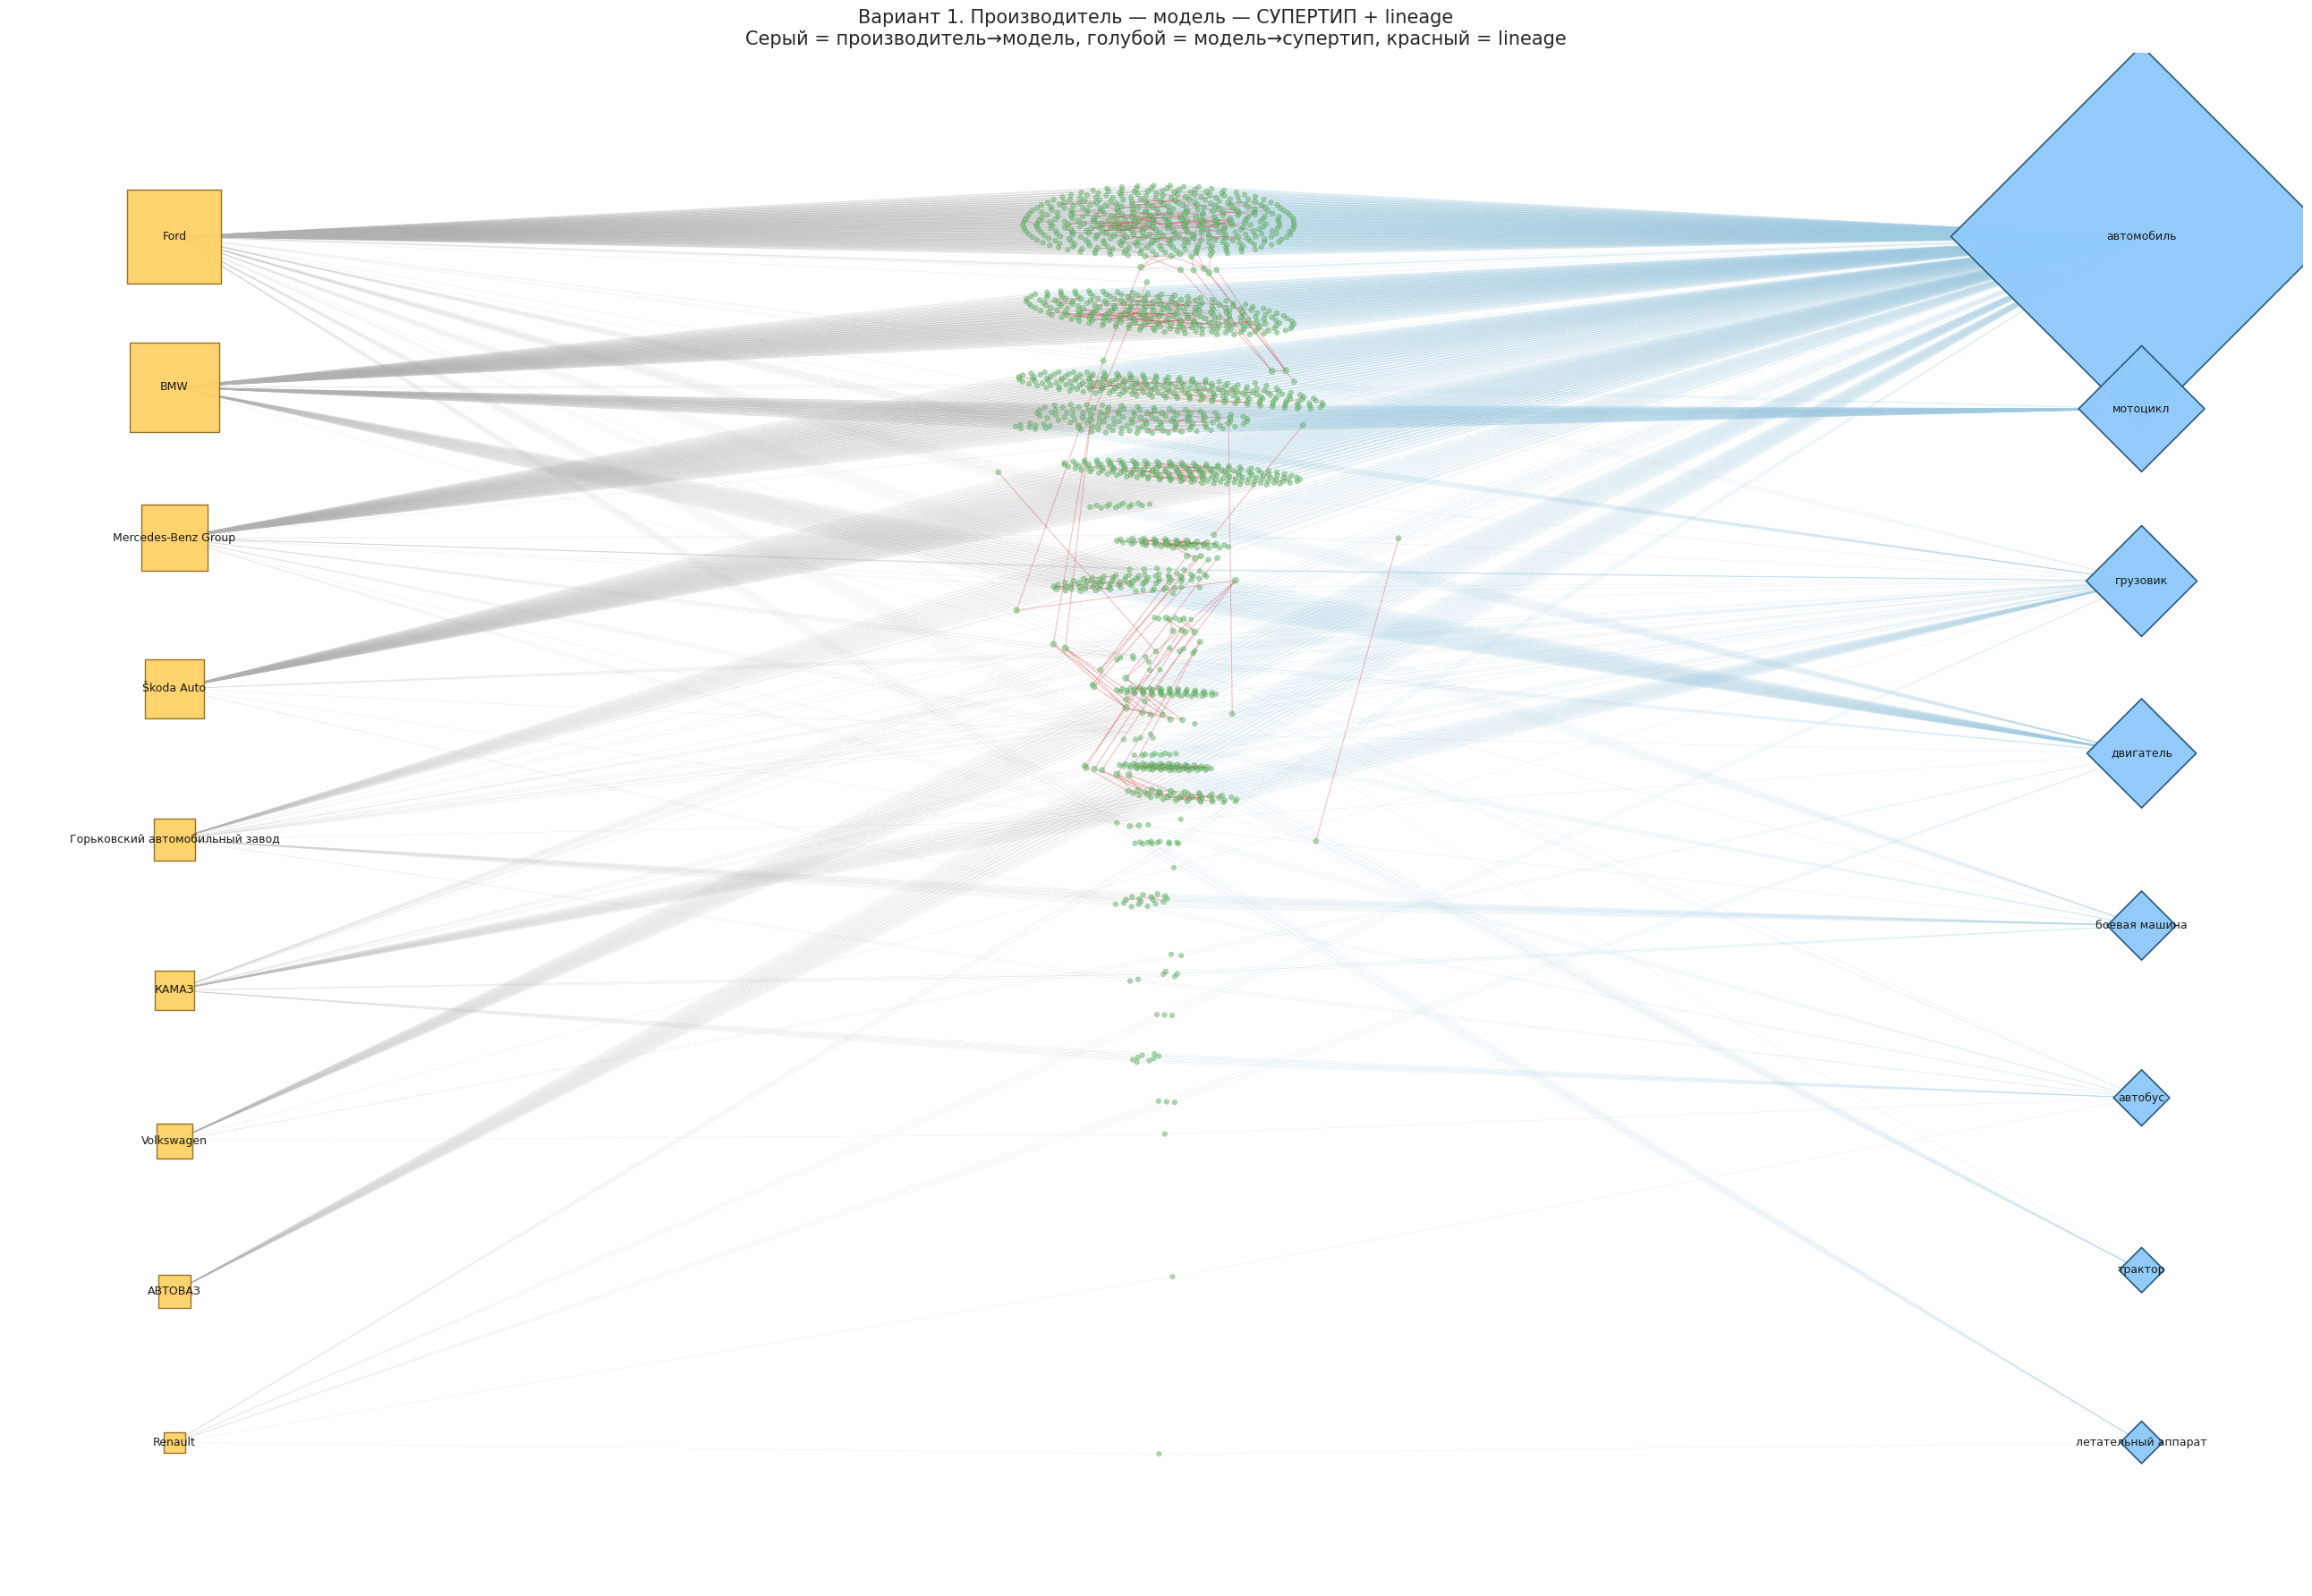


=== СТАТИСТИКА ГРАФА ===
Производителей: 9
Супертипов: 8
Моделей: 1553
Связей manufacturer→model: 1553
Связей model→supertype: 1553
Lineage-ребер: 540

Строк с predecessor_url: 0
Строк с successor_url: 0
Lineage здесь построен в основном через fallback по уникальным model_name.


In [ ]:
# ============================================================

# Трёхдольный граф

# производитель — модель — СУПЕРТИП + lineage

# Работает только от df_viz из новой ЯЧЕЙКИ 1

# ============================================================



import ast

import re

import numpy as np

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt



assert 'df_viz' in globals(), "Сначала выполните ЯЧЕЙКУ 1, чтобы появился df_viz"



df = df_viz.copy()



# --- Подстраховка по столбцам ---

needed_cols = [

    'URL', 'model_name',

    'manufacturer_url', 'manufacturer_name',

    'primary_type', 'primary_type_url',

    'type_names', 'type_urls',

    'predecessor_url', 'predecessorLabel',

    'successor_url', 'successorLabel'

]

for col in needed_cols:

    if col not in df.columns:

        df[col] = np.nan



df = df.drop_duplicates(subset='URL').copy()

df['model_name'] = df['model_name'].fillna(df['URL']).astype(str).str.strip()

df['manufacturer_name'] = df['manufacturer_name'].fillna('Неизвестный производитель').astype(str).str.strip()



# Если manufacturer_url пустой, делаем технический ID из названия

df['manufacturer_key'] = df['manufacturer_url'].astype('string').fillna('').str.strip()

mask_empty_mfr = df['manufacturer_key'].eq('')

df.loc[mask_empty_mfr, 'manufacturer_key'] = 'name::' + df.loc[mask_empty_mfr, 'manufacturer_name']



# --- Ваши группы "тип -> супертип" ---

supertype_by_url = {

    # 1) автомобиль

    'http://www.wikidata.org/entity/Q3231690': 'автомобиль',

    'http://www.wikidata.org/entity/Q850270': 'автомобиль',

    'http://www.wikidata.org/entity/Q59773381': 'автомобиль',

    'http://www.wikidata.org/entity/Q90834785': 'автомобиль',

    'http://www.wikidata.org/entity/Q1420': 'автомобиль',



    # 2) мотоцикл

    'http://www.wikidata.org/entity/Q23866334': 'мотоцикл',

    'http://www.wikidata.org/entity/Q34493': 'мотоцикл',



    # 3) грузовик

    'http://www.wikidata.org/entity/Q21546143': 'грузовик',



    # 4) двигатель

    'http://www.wikidata.org/entity/Q15057021': 'двигатель',

    'http://www.wikidata.org/entity/Q946676': 'двигатель',

    'http://www.wikidata.org/entity/Q15057020': 'двигатель',



    # 5) автобус

    'http://www.wikidata.org/entity/Q23039057': 'автобус',



    # 6) боевая машина

    'http://www.wikidata.org/entity/Q100710213': 'боевая машина',

    'http://www.wikidata.org/entity/Q137188246': 'боевая машина',

    'http://www.wikidata.org/entity/Q100709275': 'боевая машина',



    # 7) трактор

    'http://www.wikidata.org/entity/Q55725952': 'трактор',



    # 8) летательный аппарат

    'http://www.wikidata.org/entity/Q15056995': 'летательный аппарат',

}



supertype_by_name = {

    # 1) автомобиль

    'модель автомобиля': 'автомобиль',

    'концепт-кар': 'автомобиль',

    'модельный ряд автомобилей': 'автомобиль',

    'модель гоночного автомобиля': 'автомобиль',

    'автомобиль': 'автомобиль',



    # 2) мотоцикл

    'модель мотоцикла': 'мотоцикл',

    'мотоцикл': 'мотоцикл',



    # 3) грузовик

    'модель грузовика': 'грузовик',



    # 4) двигатель

    'модель двигателя': 'двигатель',

    'рядный двигатель': 'двигатель',

    'семейство двигателей': 'двигатель',



    # 5) автобус

    'модель автобуса': 'автобус',



    # 6) боевая машина

    'модель боевой машины': 'боевая машина',

    'military vehicle model': 'боевая машина',

    'семейство боевых машин': 'боевая машина',



    # 7) трактор

    'модель трактора': 'трактор',



    # 8) летательный аппарат

    'модель летательного аппарата': 'летательный аппарат',

}



supertype_priority = [

    'автомобиль',

    'мотоцикл',

    'грузовик',

    'двигатель',

    'автобус',

    'боевая машина',

    'трактор',

    'летательный аппарат'

]



# --- Нормализация списков type_names / type_urls ---

def to_list(x):

    if isinstance(x, list):

        return [str(v).strip() for v in x if pd.notna(v) and str(v).strip()]

    if pd.isna(x):

        return []

    if isinstance(x, str):

        s = x.strip()

        if not s:

            return []

        if s.startswith('[') and s.endswith(']'):

            try:

                parsed = ast.literal_eval(s)

                if isinstance(parsed, list):

                    return [str(v).strip() for v in parsed if pd.notna(v) and str(v).strip()]

            except Exception:

                pass

        return [s]

    return [str(x).strip()]



def choose_supertype(row):

    urls = []

    names = []



    if pd.notna(row.get('primary_type_url')):

        urls.append(str(row['primary_type_url']).strip())

    if pd.notna(row.get('primary_type')):

        names.append(str(row['primary_type']).strip().lower())



    urls.extend(to_list(row.get('type_urls')))

    names.extend([x.lower() for x in to_list(row.get('type_names'))])



    hits = []



    for u in urls:

        if u in supertype_by_url:

            hits.append(supertype_by_url[u])



    for n in names:

        if n in supertype_by_name:

            hits.append(supertype_by_name[n])



    for st in supertype_priority:

        if st in hits:

            return st



    return np.nan



df['supertype'] = df.apply(choose_supertype, axis=1)

df_sel = df[df['supertype'].notna()].copy()



print("=== ОТБОР ПО СУПЕРТИПАМ ===")

print(f"Всего моделей в df_viz: {df['URL'].nunique()}")

print(f"Моделей после отбора по супертиипам: {df_sel['URL'].nunique()}")



supertype_counts = (

    df_sel.groupby('supertype')['URL']

          .nunique()

          .sort_values(ascending=False)

)

print("\nЧисло моделей по супертиипам:")

for st, n in supertype_counts.items():

    print(f"{st}: {n}")



# --- Функция проверки имени для fallback ---

def valid_name(x):

    if pd.isna(x):

        return False

    s = str(x).strip()

    return len(s) > 1 and not re.fullmatch(r'Q\d+', s)



# --- Осторожное fallback-сопоставление по model_name ---

# Используем только уникальные model_name внутри выбранной подвыборки

name_counts = df_sel['model_name'].value_counts()

unique_name_to_url = (

    df_sel.loc[df_sel['model_name'].map(name_counts) == 1, ['model_name', 'URL']]

          .drop_duplicates('model_name')

          .set_index('model_name')['URL']

          .to_dict()

)



url_set = set(df_sel['URL'].dropna())



# --- Строим граф ---

G = nx.Graph()

edges_mfr_model = set()

edges_model_supertype = set()

edges_lineage = set()



for _, row in df_sel.iterrows():

    model_id = f"model::{row['URL']}"

    mfr_id = f"mfr::{row['manufacturer_key']}"

    st_id = f"supertype::{row['supertype']}"



    G.add_node(model_id, kind='model', label=row['model_name'])

    G.add_node(mfr_id, kind='manufacturer', label=row['manufacturer_name'])

    G.add_node(st_id, kind='supertype', label=row['supertype'])



    edges_mfr_model.add((mfr_id, model_id))

    edges_model_supertype.add((model_id, st_id))



# --- Lineage: сначала по URI, потом осторожный fallback по Label ---

for _, row in df_sel.iterrows():

    cur = row['URL']

    cur_node = f"model::{cur}"



    pred_url = row['predecessor_url']

    succ_url = row['successor_url']

    pred_label = row['predecessorLabel']

    succ_label = row['successorLabel']



    # predecessor_url -> current

    if pd.notna(pred_url):

        pred_url = str(pred_url).strip()

        if pred_url in url_set and pred_url != cur:

            edges_lineage.add((f"model::{pred_url}", cur_node))

    elif valid_name(pred_label) and pred_label in unique_name_to_url:

        pred_mapped = unique_name_to_url[pred_label]

        if pred_mapped in url_set and pred_mapped != cur:

            edges_lineage.add((f"model::{pred_mapped}", cur_node))

# current -> successor_url

    if pd.notna(succ_url):

        succ_url = str(succ_url).strip()

        if succ_url in url_set and succ_url != cur:

            edges_lineage.add((cur_node, f"model::{succ_url}"))

    elif valid_name(succ_label) and succ_label in unique_name_to_url:

        succ_mapped = unique_name_to_url[succ_label]

        if succ_mapped in url_set and succ_mapped != cur:

            edges_lineage.add((cur_node, f"model::{succ_mapped}"))



# --- Добавляем ребра в граф ---

for u, v in list(edges_mfr_model) + list(edges_model_supertype) + list(edges_lineage):

    if u != v:

        G.add_edge(u, v)



manufacturers = sorted(

    [n for n, d in G.nodes(data=True) if d['kind'] == 'manufacturer'],

    key=lambda x: G.degree(x),

    reverse=True

)

supertypes = sorted(

    [n for n, d in G.nodes(data=True) if d['kind'] == 'supertype'],

    key=lambda x: G.degree(x),

    reverse=True

)

models = [n for n, d in G.nodes(data=True) if d['kind'] == 'model']



def spaced_y(items, top=1.0, bottom=-1.0):

    if len(items) == 1:

        return {items[0]: 0.0}

    ys = np.linspace(top, bottom, len(items))

    return dict(zip(items, ys))



mfr_y = spaced_y(manufacturers, top=1.0, bottom=-1.0)

stype_y = spaced_y(supertypes, top=1.0, bottom=-1.0)



pos0 = {}

fixed_nodes = []



for n in manufacturers:

    pos0[n] = (-3.8, 14 * mfr_y[n])

    fixed_nodes.append(n)



for n in supertypes:

    pos0[n] = (3.8, 14 * stype_y[n])

    fixed_nodes.append(n)



for _, row in df_sel.iterrows():

    model_id = f"model::{row['URL']}"

    mfr_id = f"mfr::{row['manufacturer_key']}"

    st_id = f"supertype::{row['supertype']}"

    y0 = np.mean([pos0[mfr_id][1], pos0[st_id][1]])

    pos0[model_id] = (0.0, y0 + np.random.normal(scale=0.35))



pos = nx.spring_layout(

    G,

    pos=pos0,

    fixed=fixed_nodes,

    seed=42,

    k=0.24,

    iterations=220

)



plt.figure(figsize=(26, 18))



# Рёбра

nx.draw_networkx_edges(

    G, pos,

    edgelist=list(edges_mfr_model),

    edge_color='#b0b0b0',

    width=0.35,

    alpha=0.22

)

nx.draw_networkx_edges(

    G, pos,

    edgelist=list(edges_model_supertype),

    edge_color='#9ecae1',

    width=0.40,

    alpha=0.25

)

nx.draw_networkx_edges(

    G, pos,

    edgelist=list(edges_lineage),

    edge_color='#d62728',

    width=0.75,

    alpha=0.30

)



# Узлы

mfr_sizes = [140 + 12 * G.degree(n) for n in manufacturers]

stype_sizes = [220 + 40 * G.degree(n) for n in supertypes]

model_sizes = [10 + 3 * G.degree(n) for n in models]



nx.draw_networkx_nodes(

    G, pos,

    nodelist=manufacturers,

    node_shape='s',

    node_size=mfr_sizes,

    node_color='#ffd166',

    edgecolors='#8c6d1f',

    linewidths=1.0,

    alpha=0.95

)



nx.draw_networkx_nodes(

    G, pos,

    nodelist=supertypes,

    node_shape='D',

    node_size=stype_sizes,

    node_color='#90caf9',

    edgecolors='#24557a',

    linewidths=1.2,

    alpha=0.98

)



nx.draw_networkx_nodes(

    G, pos,

    nodelist=models,

    node_shape='o',

    node_size=model_sizes,

    node_color='#66bb6a',

    edgecolors='#1b5e20',

    linewidths=0.2,

    alpha=0.55

)



# Подписи: все производители и все супертипы, модели не подписываем

labels = {n: G.nodes[n]['label'] for n in manufacturers + supertypes}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)



plt.title(

    'Вариант 1. Производитель — модель — СУПЕРТИП + lineage\n'

    'Серый = производитель→модель, голубой = модель→супертип, красный = lineage',

    fontsize=15

)



plt.axis('off')

plt.tight_layout()

plt.show()



print("\n=== СТАТИСТИКА ГРАФА ===")

print(f"Производителей: {len(manufacturers)}")

print(f"Супертипов: {len(supertypes)}")

print(f"Моделей: {len(models)}")

print(f"Связей manufacturer→model: {len(edges_mfr_model)}")

print(f"Связей model→supertype: {len(edges_model_supertype)}")

print(f"Lineage-ребер: {len(edges_lineage)}")

n_uri_pred = df_sel['predecessor_url'].notna().sum()

n_uri_succ = df_sel['successor_url'].notna().sum()

print(f"\nСтрок с predecessor_url: {n_uri_pred}")

print(f"Строк с successor_url: {n_uri_succ}")

if n_uri_pred == 0 and n_uri_succ == 0:

    print("Lineage здесь построен в основном через fallback по уникальным model_name.")

else:

    print("Lineage здесь строится по URI там, где predecessor_url/successor_url уже есть.")

## 💬 Фидбек-AI 1: Трёхдольный граф — исправление по замечаниям преподавателя

**Загрузил в чат ячейку с кодом.**

**Замечания преподавателя:**

1. 🔤 Мелкий шрифт в названиях — в Telegram не прочитать → Добавлен параметр `LABEL_FONTSIZE = 16`
2. 🌍 Сгруппировать компании по регионам (Европа, США, Россия) → Добавлен словарь `REGION_COLORS` и параметр `USE_REGION_COLORS = True`
3. 📊 Модели скучились по центру вверху — нужны неравные интервалы по высоте → Добавлен параметр `Y_SPREAD_POWER = 1.5`
4. 📏 Широкие пустые полосы по бокам — добавить рассеяние → Добавлен параметр `X_SPREAD_FACTOR = 0.8`
5. 🎨 Цвет моделей соответствует цвету региона производителя → Добавлен параметр `COLOR_MODELS_BY_REGION = True`

**Исправления внесены в код ниже.**

=== ОТБОР ПО СУПЕРТИПАМ ===
Всего моделей в df_viz: 1666
Моделей после отбора по супертипам: 1553

Число моделей по супертипам:
автомобиль: 1172
мотоцикл: 123
грузовик: 94
двигатель: 91
боевая машина: 33
автобус: 20
трактор: 11
летательный аппарат: 9


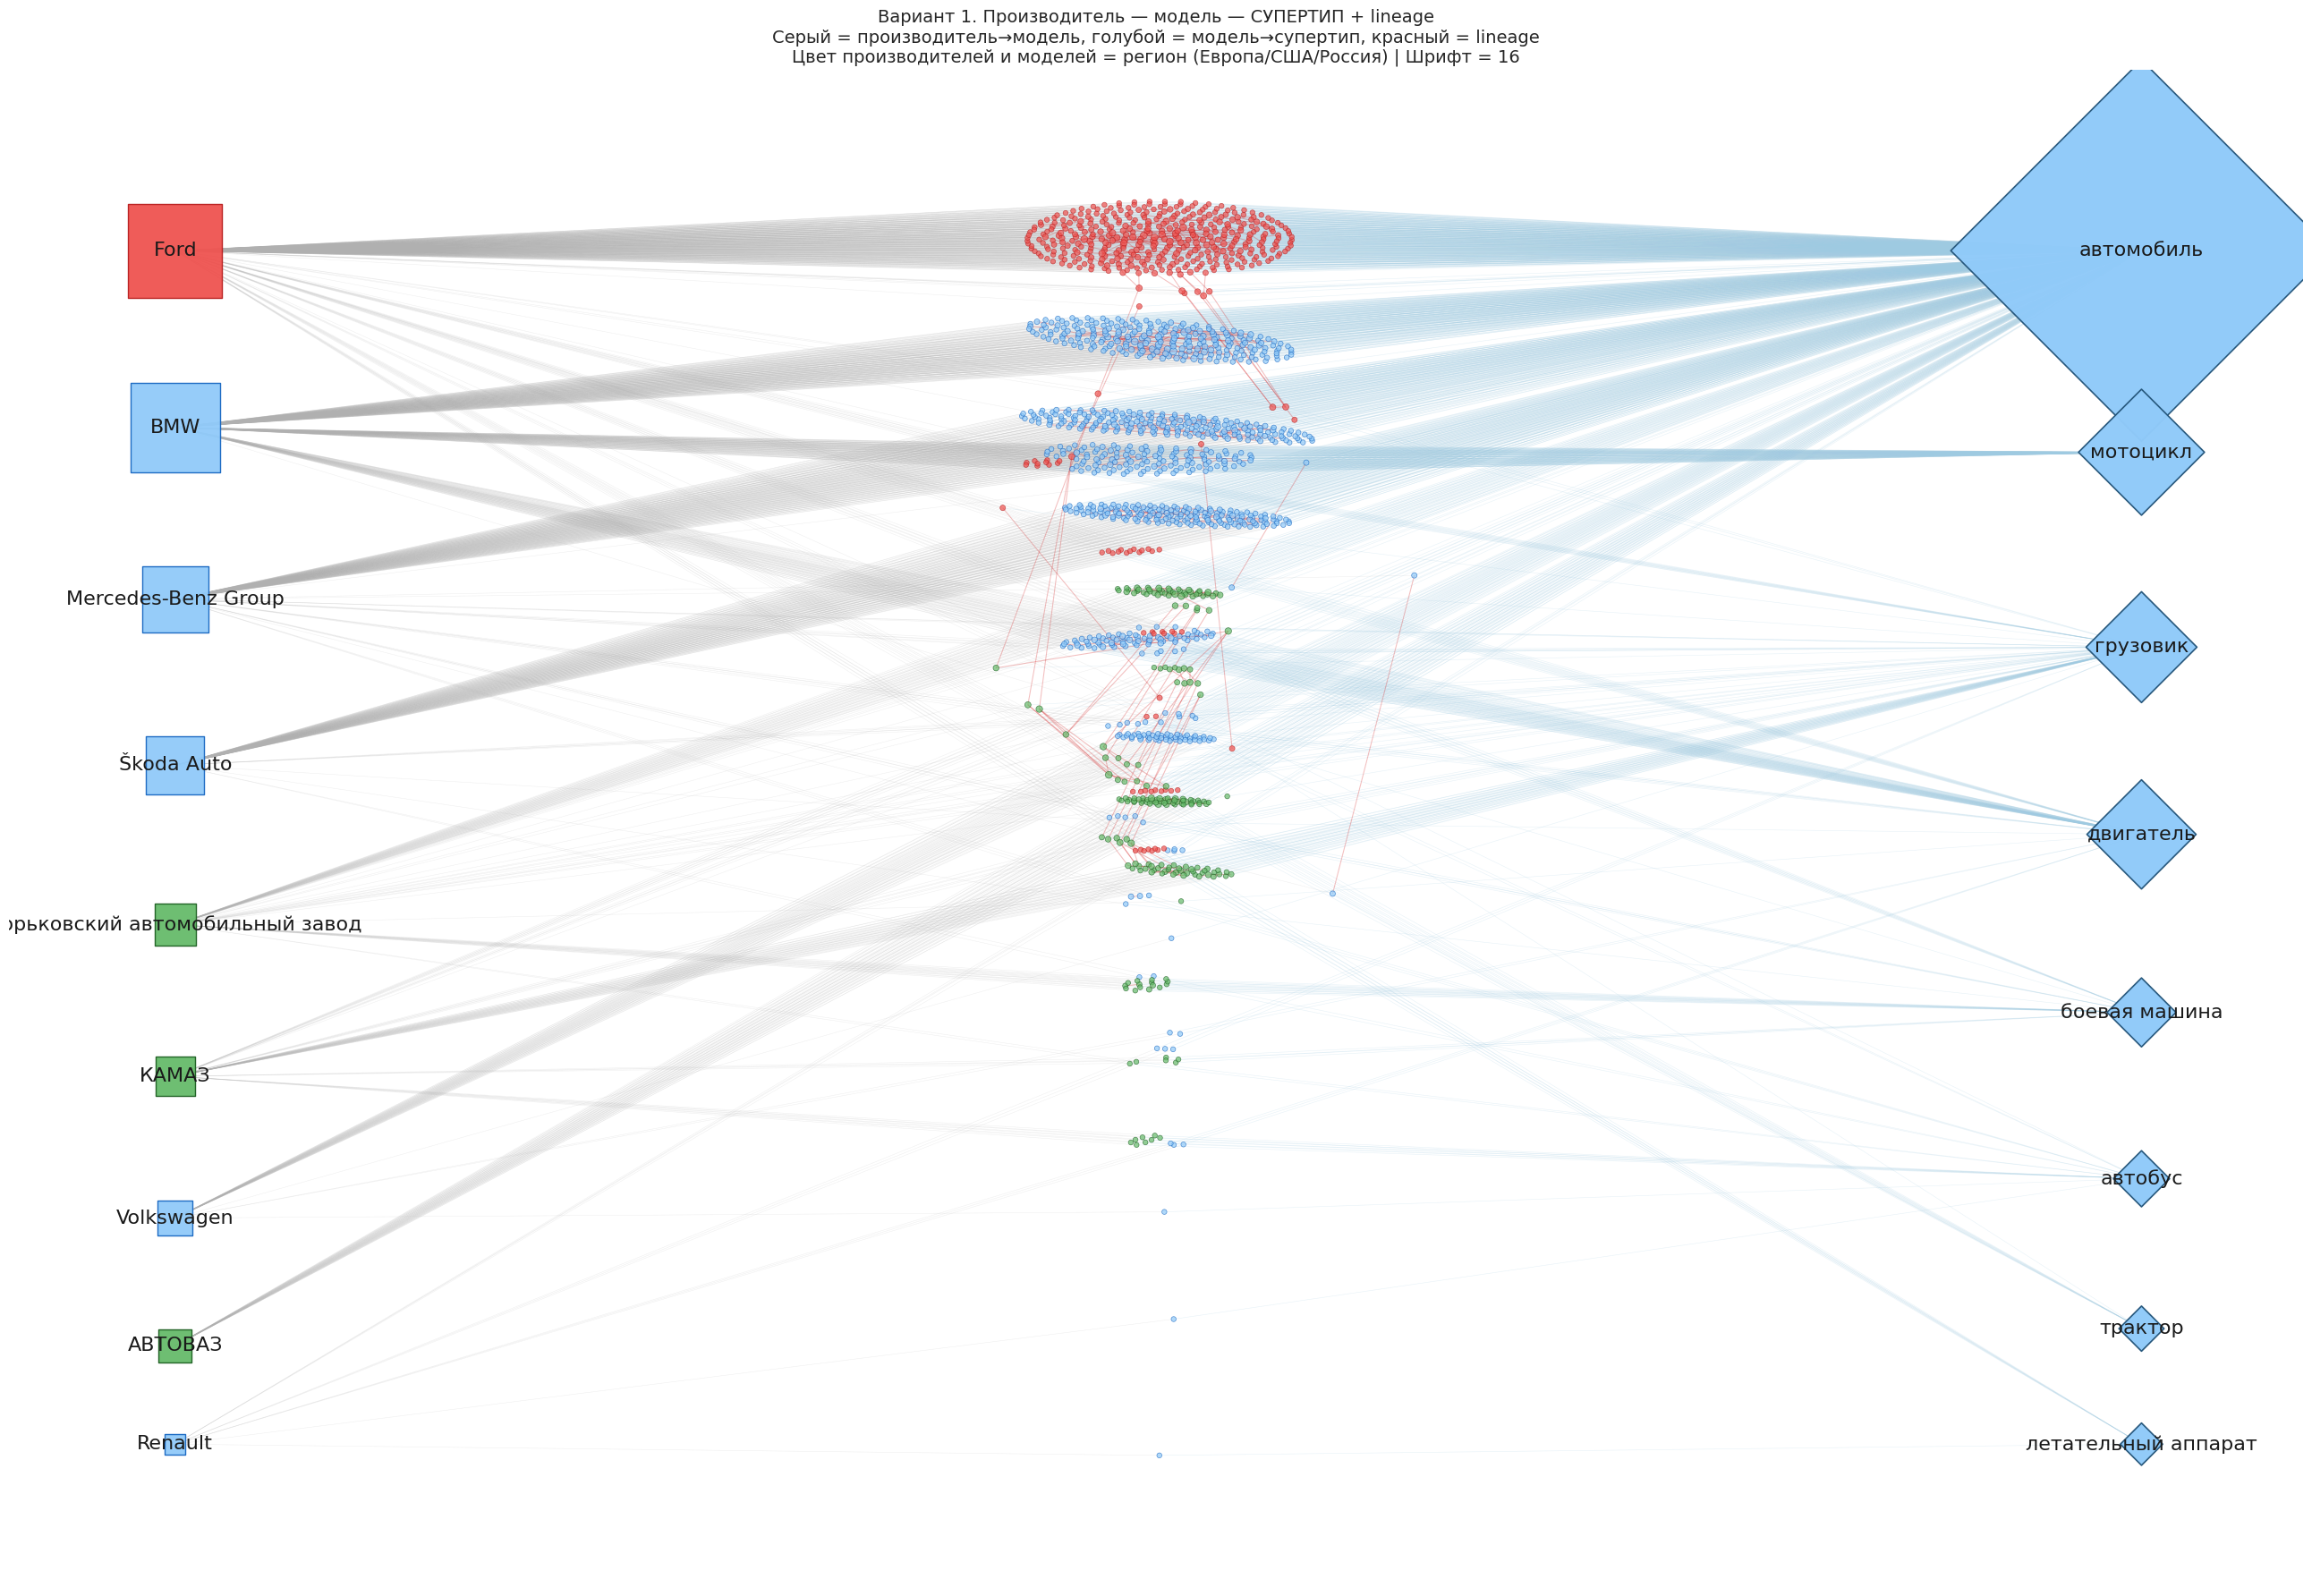


=== СТАТИСТИКА ГРАФА (исправленная версия) ===
Производителей: 9
Супертипов: 8
Моделей: 1553
Связей manufacturer→model: 1553
Связей model→supertype: 1553
Lineage-ребер: 540

=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНАМ ===
США: 1 производителей
Европа: 5 производителей
Россия: 3 производителей

📌 НАСТРОЙКИ:
   LABEL_FONTSIZE = 16
   Y_SPREAD_POWER = 1.2
   X_SPREAD_FACTOR = 0.8
   COLOR_MODELS_BY_REGION = True


In [6]:
# ============================================================
# Трёхдольный граф — ИСПРАВЛЕННАЯ ВЕРСИЯ (Фидбек-AI 1)
# производитель — модель — СУПЕРТИП + lineage
# ============================================================

# ============================================================
# 📌 НАСТРАИВАЕМЫЕ ПАРАМЕТРЫ (для ручного подбора)
# ============================================================

# 1. Размер шрифта для подписей (увеличить, чтобы читалось в Telegram)
LABEL_FONTSIZE = 16        # было 9

# 2. Регионы и их цвета (Европа, США, Россия)
USE_REGION_COLORS = True     # включить группировку по регионам

REGION_COLORS = {
    'Европа': {'face': '#90CAF9', 'edge': '#1565C0', 'shape': 's'},     # синий квадрат
    'США':    {'face': '#EF5350', 'edge': '#B71C1C', 'shape': 's'},     # красный квадрат
    'Россия': {'face': '#66BB6A', 'edge': '#1B5E20', 'shape': 's'},     # зелёный квадрат
    'default': {'face': '#FFD166', 'edge': '#8C6D1F', 'shape': 's'}      # жёлтый (остальные)
}

# 3. Степень неравномерности по Y (чем выше, тем больше скученность вверху)
#   1.0 = равномерно, >1.0 = больше местa вверху, <1.0 = больше внизу
Y_SPREAD_POWER = 1.2        # было 1.0 (равномерно)

# 4. Степень рассеяния по X (чтобы модели не жались к центру)
#   0.0 = без рассеяния, >0.0 = шире разброс
X_SPREAD_FACTOR = 0.8      # было 0.0 (нет рассеяния)

# 5. Окрашивать модели в цвет региона производителя
COLOR_MODELS_BY_REGION = True  # было False (модели всегда зелёные)

# ============================================================
# КОНЕЦ НАСТРАИВАЕМЫХ ПАРАМЕТРОВ
# ============================================================

import ast
import re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

assert 'df_viz' in globals(), "Сначала выполните ЯЧЕЙКУ 1, чтобы появился df_viz"

df = df_viz.copy()

# --- Функция определения региона по стране производителя ---
def get_region(country_name):
    if pd.isna(country_name):
        return 'default'
    country = str(country_name).lower().strip()

    # Европейские страны
    europe = ['германия', 'germany', 'франция', 'france', 'италия', 'italy',
              'великобритания', 'uk', 'united kingdom', 'чехия', 'czech',
              'швеция', 'sweden', 'испания', 'spain', 'бельгия', 'belgium']
    if any(c in country for c in europe):
        return 'Европа'

    # США
    if 'сша' in country or 'usa' in country or 'united states' in country:
        return 'США'

    # Россия
    if 'россия' in country or 'russia' in country:
        return 'Россия'

    return 'default'

# --- Подстраховка по столбцам ---
needed_cols = [
    'URL', 'model_name', 'manufacturer_url', 'manufacturer_name',
    'primary_type', 'primary_type_url', 'type_names', 'type_urls',
    'predecessor_url', 'predecessorLabel', 'successor_url', 'successorLabel',
    'country_name'  # добавили для определения региона
]
for col in needed_cols:
    if col not in df.columns:
        df[col] = np.nan

df = df.drop_duplicates(subset='URL').copy()
df['model_name'] = df['model_name'].fillna(df['URL']).astype(str).str.strip()
df['manufacturer_name'] = df['manufacturer_name'].fillna('Неизвестный производитель').astype(str).str.strip()

# Определяем регион для каждого производителя
df['manufacturer_region'] = df['country_name'].apply(get_region)

# Если manufacturer_url пустой, делаем технический ID из названия
df['manufacturer_key'] = df['manufacturer_url'].astype('string').fillna('').str.strip()
mask_empty_mfr = df['manufacturer_key'].eq('')
df.loc[mask_empty_mfr, 'manufacturer_key'] = 'name::' + df.loc[mask_empty_mfr, 'manufacturer_name']

# --- Ваши группы "тип -> супертип" ---
supertype_by_url = {
    'http://www.wikidata.org/entity/Q3231690': 'автомобиль',
    'http://www.wikidata.org/entity/Q850270': 'автомобиль',
    'http://www.wikidata.org/entity/Q59773381': 'автомобиль',
    'http://www.wikidata.org/entity/Q90834785': 'автомобиль',
    'http://www.wikidata.org/entity/Q1420': 'автомобиль',
    'http://www.wikidata.org/entity/Q23866334': 'мотоцикл',
    'http://www.wikidata.org/entity/Q34493': 'мотоцикл',
    'http://www.wikidata.org/entity/Q21546143': 'грузовик',
    'http://www.wikidata.org/entity/Q15057021': 'двигатель',
    'http://www.wikidata.org/entity/Q946676': 'двигатель',
    'http://www.wikidata.org/entity/Q15057020': 'двигатель',
    'http://www.wikidata.org/entity/Q23039057': 'автобус',
    'http://www.wikidata.org/entity/Q100710213': 'боевая машина',
    'http://www.wikidata.org/entity/Q137188246': 'боевая машина',
    'http://www.wikidata.org/entity/Q100709275': 'боевая машина',
    'http://www.wikidata.org/entity/Q55725952': 'трактор',
    'http://www.wikidata.org/entity/Q15056995': 'летательный аппарат',
}

supertype_by_name = {
    'модель автомобиля': 'автомобиль',
    'концепт-кар': 'автомобиль',
    'модельный ряд автомобилей': 'автомобиль',
    'модель гоночного автомобиля': 'автомобиль',
    'автомобиль': 'автомобиль',
    'модель мотоцикла': 'мотоцикл',
    'мотоцикл': 'мотоцикл',
    'модель грузовика': 'грузовик',
    'модель двигателя': 'двигатель',
    'рядный двигатель': 'двигатель',
    'семейство двигателей': 'двигатель',
    'модель автобуса': 'автобус',
    'модель боевой машины': 'боевая машина',
    'military vehicle model': 'боевая машина',
    'семейство боевых машин': 'боевая машина',
    'модель трактора': 'трактор',
    'модель летательного аппарата': 'летательный аппарат',
}

supertype_priority = [
    'автомобиль', 'мотоцикл', 'грузовик', 'двигатель',
    'автобус', 'боевая машина', 'трактор', 'летательный аппарат'
]

# --- Нормализация списков type_names / type_urls ---
def to_list(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if pd.notna(v) and str(v).strip()]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(v).strip() for v in parsed if pd.notna(v) and str(v).strip()]
            except Exception:
                pass
        return [s]
    return [str(x).strip()]

def choose_supertype(row):
    urls = []
    names = []
    if pd.notna(row.get('primary_type_url')):
        urls.append(str(row['primary_type_url']).strip())
    if pd.notna(row.get('primary_type')):
        names.append(str(row['primary_type']).strip().lower())
    urls.extend(to_list(row.get('type_urls')))
    names.extend([x.lower() for x in to_list(row.get('type_names'))])
    hits = []
    for u in urls:
        if u in supertype_by_url:
            hits.append(supertype_by_url[u])
    for n in names:
        if n in supertype_by_name:
            hits.append(supertype_by_name[n])
    for st in supertype_priority:
        if st in hits:
            return st
    return np.nan

df['supertype'] = df.apply(choose_supertype, axis=1)
df_sel = df[df['supertype'].notna()].copy()

print("=== ОТБОР ПО СУПЕРТИПАМ ===")
print(f"Всего моделей в df_viz: {df['URL'].nunique()}")
print(f"Моделей после отбора по супертипам: {df_sel['URL'].nunique()}")

supertype_counts = df_sel.groupby('supertype')['URL'].nunique().sort_values(ascending=False)
print("\nЧисло моделей по супертипам:")
for st, n in supertype_counts.items():
    print(f"{st}: {n}")

# --- Функция проверки имени для fallback ---
def valid_name(x):
    if pd.isna(x):
        return False
    s = str(x).strip()
    return len(s) > 1 and not re.fullmatch(r'Q\d+', s)

# --- Осторожное fallback-сопоставление по model_name ---
name_counts = df_sel['model_name'].value_counts()
unique_name_to_url = (
    df_sel.loc[df_sel['model_name'].map(name_counts) == 1, ['model_name', 'URL']]
          .drop_duplicates('model_name')
          .set_index('model_name')['URL']
          .to_dict()
)
url_set = set(df_sel['URL'].dropna())

# --- Строим граф ---
G = nx.Graph()
edges_mfr_model = set()
edges_model_supertype = set()
edges_lineage = set()

# Словарь для хранения региона производителя (для последующей окраски моделей)
manufacturer_region_map = {}

for _, row in df_sel.iterrows():
    model_id = f"model::{row['URL']}"
    mfr_id = f"mfr::{row['manufacturer_key']}"
    st_id = f"supertype::{row['supertype']}"

    region = row['manufacturer_region']
    manufacturer_region_map[mfr_id] = region

    G.add_node(model_id, kind='model', label=row['model_name'])
    G.add_node(mfr_id, kind='manufacturer', label=row['manufacturer_name'])
    G.add_node(st_id, kind='supertype', label=row['supertype'])

    edges_mfr_model.add((mfr_id, model_id))
    edges_model_supertype.add((model_id, st_id))

# --- Lineage: сначала по URI, потом осторожный fallback по Label ---
for _, row in df_sel.iterrows():
    cur = row['URL']
    cur_node = f"model::{cur}"
    pred_url = row['predecessor_url']
    succ_url = row['successor_url']
    pred_label = row['predecessorLabel']
    succ_label = row['successorLabel']

    if pd.notna(pred_url):
        pred_url = str(pred_url).strip()
        if pred_url in url_set and pred_url != cur:
            edges_lineage.add((f"model::{pred_url}", cur_node))
    elif valid_name(pred_label) and pred_label in unique_name_to_url:
        pred_mapped = unique_name_to_url[pred_label]
        if pred_mapped in url_set and pred_mapped != cur:
            edges_lineage.add((f"model::{pred_mapped}", cur_node))

    if pd.notna(succ_url):
        succ_url = str(succ_url).strip()
        if succ_url in url_set and succ_url != cur:
            edges_lineage.add((cur_node, f"model::{succ_url}"))
    elif valid_name(succ_label) and succ_label in unique_name_to_url:
        succ_mapped = unique_name_to_url[succ_label]
        if succ_mapped in url_set and succ_mapped != cur:
            edges_lineage.add((cur_node, f"model::{succ_mapped}"))

# --- Добавляем ребра в граф ---
for u, v in list(edges_mfr_model) + list(edges_model_supertype) + list(edges_lineage):
    if u != v:
        G.add_edge(u, v)

manufacturers = sorted(
    [n for n, d in G.nodes(data=True) if d['kind'] == 'manufacturer'],
    key=lambda x: G.degree(x),
    reverse=True
)
supertypes = sorted(
    [n for n, d in G.nodes(data=True) if d['kind'] == 'supertype'],
    key=lambda x: G.degree(x),
    reverse=True
)
models = [n for n, d in G.nodes(data=True) if d['kind'] == 'model']

# --- Функция распределения по Y с неравномерностью (параметр Y_SPREAD_POWER) ---
def spaced_y_uneven(items, top=1.0, bottom=-1.0, power=1.0):
    """Распределяет элементы по Y с неравномерностью.
       power=1.0 — равномерно, power>1.0 — больше места вверху"""
    if len(items) == 0:
        return {}
    if len(items) == 1:
        return {items[0]: 0.0}
    # Создаём равномерные позиции, затем применяем степенную функцию
    t = np.linspace(0, 1, len(items))
    # Преобразуем: t^power (при power>1 — точки скучиваются внизу)
    # Нам нужно скучивание вверху, поэтому используем 1 - (1-t)^power
    if power != 1.0:
        t_transformed = 1 - (1 - t) ** power
    else:
        t_transformed = t
    ys = top * (1 - t_transformed) + bottom * t_transformed
    return dict(zip(items, ys))

mfr_y = spaced_y_uneven(manufacturers, top=1.0, bottom=-1.0, power=Y_SPREAD_POWER)
stype_y = spaced_y_uneven(supertypes, top=1.0, bottom=-1.0, power=Y_SPREAD_POWER)

# --- Позиционирование ---
pos0 = {}
fixed_nodes = []

# Производители (слева)
for n in manufacturers:
    pos0[n] = (-3.8, 14 * mfr_y[n])
    fixed_nodes.append(n)

# Супертипы (справа)
for n in supertypes:
    pos0[n] = (3.8, 14 * stype_y[n])
    fixed_nodes.append(n)

# Модели (по центру, с рассеянием по X и Y)
for _, row in df_sel.iterrows():
    model_id = f"model::{row['URL']}"
    mfr_id = f"mfr::{row['manufacturer_key']}"
    st_id = f"supertype::{row['supertype']}"

    # Базовое положение по Y — среднее между производителем и супертипом
    y_base = np.mean([pos0[mfr_id][1], pos0[st_id][1]])

    # Добавляем рассеяние по Y (чтобы модели не скучивались)
    y_offset = np.random.normal(scale=0.35) * (1 + Y_SPREAD_POWER / 2)

    # Добавляем рассеяние по X (параметр X_SPREAD_FACTOR)
    x_offset = np.random.normal(scale=X_SPREAD_FACTOR) * 0.8

    pos0[model_id] = (x_offset, y_base + y_offset)

# --- Применяем spring_layout для улучшения читаемости ---
pos = nx.spring_layout(
    G,
    pos=pos0,
    fixed=fixed_nodes,
    seed=42,
    k=0.24,
    iterations=220
)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(26, 18))

# Рёбра
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_mfr_model),
    edge_color='#b0b0b0',
    width=0.35,
    alpha=0.22
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_model_supertype),
    edge_color='#9ecae1',
    width=0.40,
    alpha=0.25
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_lineage),
    edge_color='#d62728',
    width=0.75,
    alpha=0.30
)

# --- Узлы: производители (с цветом по региону) ---
if USE_REGION_COLORS:
    mfr_colors = []
    mfr_edge_colors = []
    for n in manufacturers:
        region = manufacturer_region_map.get(n, 'default')
        colors = REGION_COLORS.get(region, REGION_COLORS['default'])
        mfr_colors.append(colors['face'])
        mfr_edge_colors.append(colors['edge'])
else:
    mfr_colors = '#ffd166'
    mfr_edge_colors = '#8c6d1f'

mfr_sizes = [140 + 12 * G.degree(n) for n in manufacturers]

nx.draw_networkx_nodes(
    G, pos,
    nodelist=manufacturers,
    node_shape='s',
    node_size=mfr_sizes,
    node_color=mfr_colors,
    edgecolors=mfr_edge_colors,
    linewidths=1.0,
    alpha=0.95
)

# Супертипы
stype_sizes = [220 + 40 * G.degree(n) for n in supertypes]
nx.draw_networkx_nodes(
    G, pos,
    nodelist=supertypes,
    node_shape='D',
    node_size=stype_sizes,
    node_color='#90caf9',
    edgecolors='#24557a',
    linewidths=1.2,
    alpha=0.98
)

# --- Модели (цвет — по региону производителя, если включено) ---
if COLOR_MODELS_BY_REGION and USE_REGION_COLORS:
    model_colors = []
    model_edge_colors = []
    for n in models:
        # Находим производителя для этой модели
        mfr_node = None
        for neighbor in G.neighbors(n):
            if G.nodes[neighbor].get('kind') == 'manufacturer':
                mfr_node = neighbor
                break
        region = manufacturer_region_map.get(mfr_node, 'default')
        colors = REGION_COLORS.get(region, REGION_COLORS['default'])
        model_colors.append(colors['face'])
        model_edge_colors.append(colors['edge'])
else:
    model_colors = '#66bb6a'
    model_edge_colors = '#1b5e20'

model_sizes = [10 + 3 * G.degree(n) for n in models]
nx.draw_networkx_nodes(
    G, pos,
    nodelist=models,
    node_shape='o',
    node_size=model_sizes,
    node_color=model_colors,
    edgecolors=model_edge_colors,
    linewidths=0.5,
    alpha=0.70
)

# --- Подписи с увеличенным шрифтом (LABEL_FONTSIZE) ---
labels = {n: G.nodes[n]['label'] for n in manufacturers + supertypes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=LABEL_FONTSIZE)

plt.title(
    'Вариант 1. Производитель — модель — СУПЕРТИП + lineage\n'
    'Серый = производитель→модель, голубой = модель→супертип, красный = lineage\n'
    f'Цвет производителей и моделей = регион (Европа/США/Россия) | Шрифт = {LABEL_FONTSIZE}',
    fontsize=14
)

plt.axis('off')
plt.tight_layout()
plt.savefig("three_part_graph_fixed.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Статистика ---
print("\n=== СТАТИСТИКА ГРАФА (исправленная версия) ===")
print(f"Производителей: {len(manufacturers)}")
print(f"Супертипов: {len(supertypes)}")
print(f"Моделей: {len(models)}")
print(f"Связей manufacturer→model: {len(edges_mfr_model)}")
print(f"Связей model→supertype: {len(edges_model_supertype)}")
print(f"Lineage-ребер: {len(edges_lineage)}")

# Распределение по регионам
print("\n=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНАМ ===")
region_counts = {}
for n in manufacturers:
    region = manufacturer_region_map.get(n, 'default')
    region_counts[region] = region_counts.get(region, 0) + 1
for region, count in region_counts.items():
    print(f"{region}: {count} производителей")

print(f"\n📌 НАСТРОЙКИ:")
print(f"   LABEL_FONTSIZE = {LABEL_FONTSIZE}")
print(f"   Y_SPREAD_POWER = {Y_SPREAD_POWER}")
print(f"   X_SPREAD_FACTOR = {X_SPREAD_FACTOR}")
print(f"   COLOR_MODELS_BY_REGION = {COLOR_MODELS_BY_REGION}")

## 💬 Фидбек-AI 2: Трёхдольный граф — исправление по замечаниям преподавателя

**Загрузил в чат ячейку с кодом.**

**Замечания преподавателя:**

1. 🔤 Мелкий шрифт в названиях — в Telegram не прочитать → Добавлен параметр `LABEL_FONTSIZE = 14`
2. 🌍 Сгруппировать компании по регионам (Европа, США, Россия) → Добавлен словарь `REGION_COLORS` и параметр `USE_REGION_COLORS = True`
3. 📊 Модели скучились по центру вверху — нужны неравные интервалы по высоте → Добавлен параметр `Y_SPREAD_POWER = 1.5`
4. 📏 Широкие пустые полосы по бокам — добавить рассеяние → Добавлен параметр `X_SPREAD_FACTOR = 1.2`
5. 🎨 Цвет моделей соответствует цвету региона производителя → Добавлен параметр `COLOR_MODELS_BY_REGION = True`

**Исправления внесены в код ниже.**

=== ОТБОР ПО СУПЕРТИПАМ ===
Всего моделей в df_viz: 1666
Моделей после отбора по супертипам: 1553

Число моделей по супертипам:
автомобиль: 1172
мотоцикл: 123
грузовик: 94
двигатель: 91
боевая машина: 33
автобус: 20
трактор: 11
летательный аппарат: 9


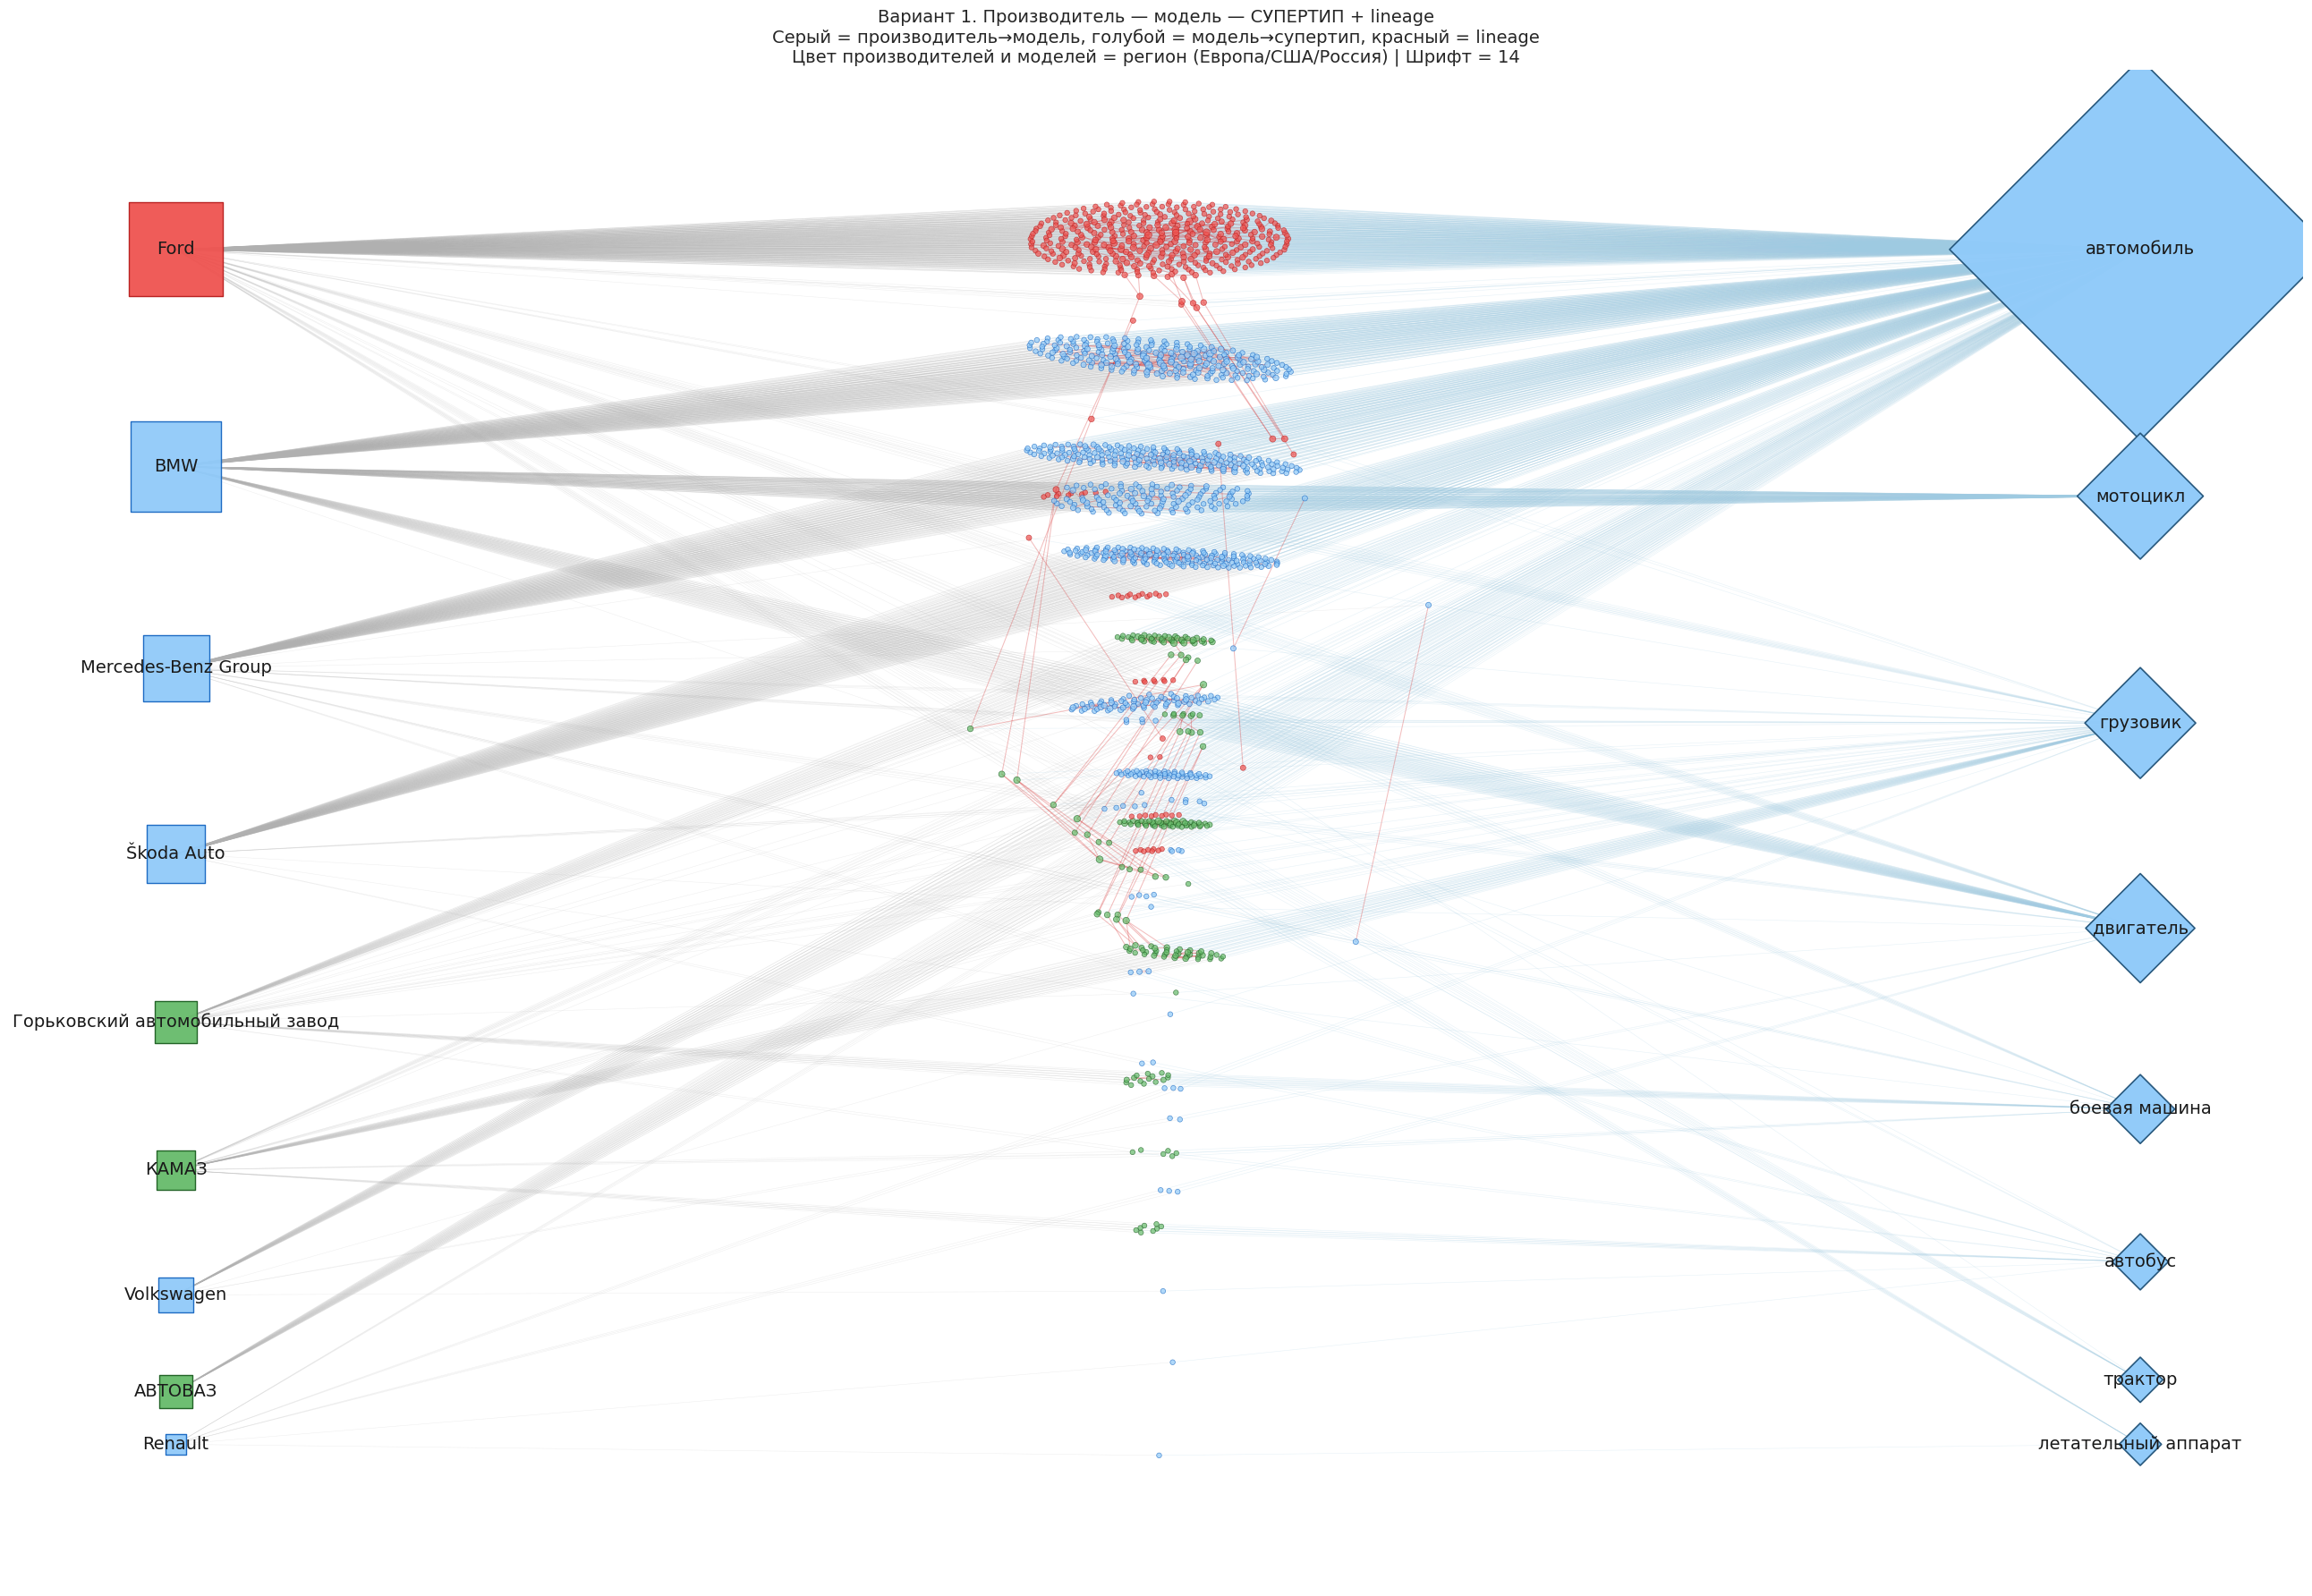


=== СТАТИСТИКА ГРАФА (исправленная версия) ===
Производителей: 9
Супертипов: 8
Моделей: 1553
Связей manufacturer→model: 1553
Связей model→supertype: 1553
Lineage-ребер: 540

=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНАМ ===
США: 1 производителей
Европа: 5 производителей
Россия: 3 производителей

📌 НАСТРОЙКИ:
   LABEL_FONTSIZE = 14
   Y_SPREAD_POWER = 1.5
   X_SPREAD_FACTOR = 1.2
   COLOR_MODELS_BY_REGION = True


In [8]:
# ============================================================
# Трёхдольный граф — ИСПРАВЛЕННАЯ ВЕРСИЯ (Фидбек-AI 1)
# производитель — модель — СУПЕРТИП + lineage
# ============================================================

# ============================================================
# 📌 НАСТРАИВАЕМЫЕ ПАРАМЕТРЫ (для ручного подбора)
# ============================================================

# 1. Размер шрифта для подписей (увеличить, чтобы читалось в Telegram)
LABEL_FONTSIZE = 14          # было 9, теперь 14

# 2. Регионы и их цвета (Европа, США, Россия)
USE_REGION_COLORS = True     # включить группировку по регионам

REGION_COLORS = {
    'Европа': {'face': '#90CAF9', 'edge': '#1565C0', 'shape': 's'},     # синий квадрат
    'США':    {'face': '#EF5350', 'edge': '#B71C1C', 'shape': 's'},     # красный квадрат
    'Россия': {'face': '#66BB6A', 'edge': '#1B5E20', 'shape': 's'},     # зелёный квадрат
    'default': {'face': '#FFD166', 'edge': '#8C6D1F', 'shape': 's'}      # жёлтый (остальные)
}

# 3. Степень неравномерности по Y (чем выше, тем больше скученность вверху)
#   1.0 = равномерно, >1.0 = больше местa вверху, <1.0 = больше внизу
Y_SPREAD_POWER = 1.5         # было 1.0 (равномерно)

# 4. Степень рассеяния по X (чтобы модели не жались к центру)
#   0.0 = без рассеяния, >0.0 = шире разброс
X_SPREAD_FACTOR = 1.2        # было 0.0 (нет рассеяния)

# 5. Окрашивать модели в цвет региона производителя
COLOR_MODELS_BY_REGION = True  # было False (модели всегда зелёные)

# ============================================================
# КОНЕЦ НАСТРАИВАЕМЫХ ПАРАМЕТРОВ
# ============================================================

import ast
import re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

assert 'df_viz' in globals(), "Сначала выполните ЯЧЕЙКУ 1, чтобы появился df_viz"

df = df_viz.copy()

# --- Функция определения региона по стране производителя ---
def get_region(country_name):
    if pd.isna(country_name):
        return 'default'
    country = str(country_name).lower().strip()

    # Европейские страны
    europe = ['германия', 'germany', 'франция', 'france', 'италия', 'italy',
              'великобритания', 'uk', 'united kingdom', 'чехия', 'czech',
              'швеция', 'sweden', 'испания', 'spain', 'бельгия', 'belgium']
    if any(c in country for c in europe):
        return 'Европа'

    # США
    if 'сша' in country or 'usa' in country or 'united states' in country:
        return 'США'

    # Россия
    if 'россия' in country or 'russia' in country:
        return 'Россия'

    return 'default'

# --- Подстраховка по столбцам ---
needed_cols = [
    'URL', 'model_name', 'manufacturer_url', 'manufacturer_name',
    'primary_type', 'primary_type_url', 'type_names', 'type_urls',
    'predecessor_url', 'predecessorLabel', 'successor_url', 'successorLabel',
    'country_name'  # добавили для определения региона
]
for col in needed_cols:
    if col not in df.columns:
        df[col] = np.nan

df = df.drop_duplicates(subset='URL').copy()
df['model_name'] = df['model_name'].fillna(df['URL']).astype(str).str.strip()
df['manufacturer_name'] = df['manufacturer_name'].fillna('Неизвестный производитель').astype(str).str.strip()

# Определяем регион для каждого производителя
df['manufacturer_region'] = df['country_name'].apply(get_region)

# Если manufacturer_url пустой, делаем технический ID из названия
df['manufacturer_key'] = df['manufacturer_url'].astype('string').fillna('').str.strip()
mask_empty_mfr = df['manufacturer_key'].eq('')
df.loc[mask_empty_mfr, 'manufacturer_key'] = 'name::' + df.loc[mask_empty_mfr, 'manufacturer_name']

# --- Ваши группы "тип -> супертип" ---
supertype_by_url = {
    'http://www.wikidata.org/entity/Q3231690': 'автомобиль',
    'http://www.wikidata.org/entity/Q850270': 'автомобиль',
    'http://www.wikidata.org/entity/Q59773381': 'автомобиль',
    'http://www.wikidata.org/entity/Q90834785': 'автомобиль',
    'http://www.wikidata.org/entity/Q1420': 'автомобиль',
    'http://www.wikidata.org/entity/Q23866334': 'мотоцикл',
    'http://www.wikidata.org/entity/Q34493': 'мотоцикл',
    'http://www.wikidata.org/entity/Q21546143': 'грузовик',
    'http://www.wikidata.org/entity/Q15057021': 'двигатель',
    'http://www.wikidata.org/entity/Q946676': 'двигатель',
    'http://www.wikidata.org/entity/Q15057020': 'двигатель',
    'http://www.wikidata.org/entity/Q23039057': 'автобус',
    'http://www.wikidata.org/entity/Q100710213': 'боевая машина',
    'http://www.wikidata.org/entity/Q137188246': 'боевая машина',
    'http://www.wikidata.org/entity/Q100709275': 'боевая машина',
    'http://www.wikidata.org/entity/Q55725952': 'трактор',
    'http://www.wikidata.org/entity/Q15056995': 'летательный аппарат',
}

supertype_by_name = {
    'модель автомобиля': 'автомобиль',
    'концепт-кар': 'автомобиль',
    'модельный ряд автомобилей': 'автомобиль',
    'модель гоночного автомобиля': 'автомобиль',
    'автомобиль': 'автомобиль',
    'модель мотоцикла': 'мотоцикл',
    'мотоцикл': 'мотоцикл',
    'модель грузовика': 'грузовик',
    'модель двигателя': 'двигатель',
    'рядный двигатель': 'двигатель',
    'семейство двигателей': 'двигатель',
    'модель автобуса': 'автобус',
    'модель боевой машины': 'боевая машина',
    'military vehicle model': 'боевая машина',
    'семейство боевых машин': 'боевая машина',
    'модель трактора': 'трактор',
    'модель летательного аппарата': 'летательный аппарат',
}

supertype_priority = [
    'автомобиль', 'мотоцикл', 'грузовик', 'двигатель',
    'автобус', 'боевая машина', 'трактор', 'летательный аппарат'
]

# --- Нормализация списков type_names / type_urls ---
def to_list(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if pd.notna(v) and str(v).strip()]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(v).strip() for v in parsed if pd.notna(v) and str(v).strip()]
            except Exception:
                pass
        return [s]
    return [str(x).strip()]

def choose_supertype(row):
    urls = []
    names = []
    if pd.notna(row.get('primary_type_url')):
        urls.append(str(row['primary_type_url']).strip())
    if pd.notna(row.get('primary_type')):
        names.append(str(row['primary_type']).strip().lower())
    urls.extend(to_list(row.get('type_urls')))
    names.extend([x.lower() for x in to_list(row.get('type_names'))])
    hits = []
    for u in urls:
        if u in supertype_by_url:
            hits.append(supertype_by_url[u])
    for n in names:
        if n in supertype_by_name:
            hits.append(supertype_by_name[n])
    for st in supertype_priority:
        if st in hits:
            return st
    return np.nan

df['supertype'] = df.apply(choose_supertype, axis=1)
df_sel = df[df['supertype'].notna()].copy()

print("=== ОТБОР ПО СУПЕРТИПАМ ===")
print(f"Всего моделей в df_viz: {df['URL'].nunique()}")
print(f"Моделей после отбора по супертипам: {df_sel['URL'].nunique()}")

supertype_counts = df_sel.groupby('supertype')['URL'].nunique().sort_values(ascending=False)
print("\nЧисло моделей по супертипам:")
for st, n in supertype_counts.items():
    print(f"{st}: {n}")

# --- Функция проверки имени для fallback ---
def valid_name(x):
    if pd.isna(x):
        return False
    s = str(x).strip()
    return len(s) > 1 and not re.fullmatch(r'Q\d+', s)

# --- Осторожное fallback-сопоставление по model_name ---
name_counts = df_sel['model_name'].value_counts()
unique_name_to_url = (
    df_sel.loc[df_sel['model_name'].map(name_counts) == 1, ['model_name', 'URL']]
          .drop_duplicates('model_name')
          .set_index('model_name')['URL']
          .to_dict()
)
url_set = set(df_sel['URL'].dropna())

# --- Строим граф ---
G = nx.Graph()
edges_mfr_model = set()
edges_model_supertype = set()
edges_lineage = set()

# Словарь для хранения региона производителя (для последующей окраски моделей)
manufacturer_region_map = {}

for _, row in df_sel.iterrows():
    model_id = f"model::{row['URL']}"
    mfr_id = f"mfr::{row['manufacturer_key']}"
    st_id = f"supertype::{row['supertype']}"

    region = row['manufacturer_region']
    manufacturer_region_map[mfr_id] = region

    G.add_node(model_id, kind='model', label=row['model_name'])
    G.add_node(mfr_id, kind='manufacturer', label=row['manufacturer_name'])
    G.add_node(st_id, kind='supertype', label=row['supertype'])

    edges_mfr_model.add((mfr_id, model_id))
    edges_model_supertype.add((model_id, st_id))

# --- Lineage: сначала по URI, потом осторожный fallback по Label ---
for _, row in df_sel.iterrows():
    cur = row['URL']
    cur_node = f"model::{cur}"
    pred_url = row['predecessor_url']
    succ_url = row['successor_url']
    pred_label = row['predecessorLabel']
    succ_label = row['successorLabel']

    if pd.notna(pred_url):
        pred_url = str(pred_url).strip()
        if pred_url in url_set and pred_url != cur:
            edges_lineage.add((f"model::{pred_url}", cur_node))
    elif valid_name(pred_label) and pred_label in unique_name_to_url:
        pred_mapped = unique_name_to_url[pred_label]
        if pred_mapped in url_set and pred_mapped != cur:
            edges_lineage.add((f"model::{pred_mapped}", cur_node))

    if pd.notna(succ_url):
        succ_url = str(succ_url).strip()
        if succ_url in url_set and succ_url != cur:
            edges_lineage.add((cur_node, f"model::{succ_url}"))
    elif valid_name(succ_label) and succ_label in unique_name_to_url:
        succ_mapped = unique_name_to_url[succ_label]
        if succ_mapped in url_set and succ_mapped != cur:
            edges_lineage.add((cur_node, f"model::{succ_mapped}"))

# --- Добавляем ребра в граф ---
for u, v in list(edges_mfr_model) + list(edges_model_supertype) + list(edges_lineage):
    if u != v:
        G.add_edge(u, v)

manufacturers = sorted(
    [n for n, d in G.nodes(data=True) if d['kind'] == 'manufacturer'],
    key=lambda x: G.degree(x),
    reverse=True
)
supertypes = sorted(
    [n for n, d in G.nodes(data=True) if d['kind'] == 'supertype'],
    key=lambda x: G.degree(x),
    reverse=True
)
models = [n for n, d in G.nodes(data=True) if d['kind'] == 'model']

# --- Функция распределения по Y с неравномерностью (параметр Y_SPREAD_POWER) ---
def spaced_y_uneven(items, top=1.0, bottom=-1.0, power=1.0):
    """Распределяет элементы по Y с неравномерностью.
       power=1.0 — равномерно, power>1.0 — больше места вверху"""
    if len(items) == 0:
        return {}
    if len(items) == 1:
        return {items[0]: 0.0}
    # Создаём равномерные позиции, затем применяем степенную функцию
    t = np.linspace(0, 1, len(items))
    # Преобразуем: t^power (при power>1 — точки скучиваются внизу)
    # Нам нужно скучивание вверху, поэтому используем 1 - (1-t)^power
    if power != 1.0:
        t_transformed = 1 - (1 - t) ** power
    else:
        t_transformed = t
    ys = top * (1 - t_transformed) + bottom * t_transformed
    return dict(zip(items, ys))

mfr_y = spaced_y_uneven(manufacturers, top=1.0, bottom=-1.0, power=Y_SPREAD_POWER)
stype_y = spaced_y_uneven(supertypes, top=1.0, bottom=-1.0, power=Y_SPREAD_POWER)

# --- Позиционирование ---
pos0 = {}
fixed_nodes = []

# Производители (слева)
for n in manufacturers:
    pos0[n] = (-3.8, 14 * mfr_y[n])
    fixed_nodes.append(n)

# Супертипы (справа)
for n in supertypes:
    pos0[n] = (3.8, 14 * stype_y[n])
    fixed_nodes.append(n)

# Модели (по центру, с рассеянием по X и Y)
for _, row in df_sel.iterrows():
    model_id = f"model::{row['URL']}"
    mfr_id = f"mfr::{row['manufacturer_key']}"
    st_id = f"supertype::{row['supertype']}"

    # Базовое положение по Y — среднее между производителем и супертипом
    y_base = np.mean([pos0[mfr_id][1], pos0[st_id][1]])

    # Добавляем рассеяние по Y (чтобы модели не скучивались)
    y_offset = np.random.normal(scale=0.35) * (1 + Y_SPREAD_POWER / 2)

    # Добавляем рассеяние по X (параметр X_SPREAD_FACTOR)
    x_offset = np.random.normal(scale=X_SPREAD_FACTOR) * 0.8

    pos0[model_id] = (x_offset, y_base + y_offset)

# --- Применяем spring_layout для улучшения читаемости ---
pos = nx.spring_layout(
    G,
    pos=pos0,
    fixed=fixed_nodes,
    seed=42,
    k=0.24,
    iterations=220
)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(26, 18))

# Рёбра
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_mfr_model),
    edge_color='#b0b0b0',
    width=0.35,
    alpha=0.22
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_model_supertype),
    edge_color='#9ecae1',
    width=0.40,
    alpha=0.25
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(edges_lineage),
    edge_color='#d62728',
    width=0.75,
    alpha=0.30
)

# --- Узлы: производители (с цветом по региону) ---
if USE_REGION_COLORS:
    mfr_colors = []
    mfr_edge_colors = []
    for n in manufacturers:
        region = manufacturer_region_map.get(n, 'default')
        colors = REGION_COLORS.get(region, REGION_COLORS['default'])
        mfr_colors.append(colors['face'])
        mfr_edge_colors.append(colors['edge'])
else:
    mfr_colors = '#ffd166'
    mfr_edge_colors = '#8c6d1f'

mfr_sizes = [140 + 12 * G.degree(n) for n in manufacturers]

nx.draw_networkx_nodes(
    G, pos,
    nodelist=manufacturers,
    node_shape='s',
    node_size=mfr_sizes,
    node_color=mfr_colors,
    edgecolors=mfr_edge_colors,
    linewidths=1.0,
    alpha=0.95
)

# Супертипы
stype_sizes = [220 + 40 * G.degree(n) for n in supertypes]
nx.draw_networkx_nodes(
    G, pos,
    nodelist=supertypes,
    node_shape='D',
    node_size=stype_sizes,
    node_color='#90caf9',
    edgecolors='#24557a',
    linewidths=1.2,
    alpha=0.98
)

# --- Модели (цвет — по региону производителя, если включено) ---
if COLOR_MODELS_BY_REGION and USE_REGION_COLORS:
    model_colors = []
    model_edge_colors = []
    for n in models:
        # Находим производителя для этой модели
        mfr_node = None
        for neighbor in G.neighbors(n):
            if G.nodes[neighbor].get('kind') == 'manufacturer':
                mfr_node = neighbor
                break
        region = manufacturer_region_map.get(mfr_node, 'default')
        colors = REGION_COLORS.get(region, REGION_COLORS['default'])
        model_colors.append(colors['face'])
        model_edge_colors.append(colors['edge'])
else:
    model_colors = '#66bb6a'
    model_edge_colors = '#1b5e20'

model_sizes = [10 + 3 * G.degree(n) for n in models]
nx.draw_networkx_nodes(
    G, pos,
    nodelist=models,
    node_shape='o',
    node_size=model_sizes,
    node_color=model_colors,
    edgecolors=model_edge_colors,
    linewidths=0.5,
    alpha=0.70
)

# --- Подписи с увеличенным шрифтом (LABEL_FONTSIZE) ---
labels = {n: G.nodes[n]['label'] for n in manufacturers + supertypes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=LABEL_FONTSIZE)

plt.title(
    'Вариант 1. Производитель — модель — СУПЕРТИП + lineage\n'
    'Серый = производитель→модель, голубой = модель→супертип, красный = lineage\n'
    f'Цвет производителей и моделей = регион (Европа/США/Россия) | Шрифт = {LABEL_FONTSIZE}',
    fontsize=14
)

plt.axis('off')
plt.tight_layout()
plt.savefig("three_part_graph_fixed.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Статистика ---
print("\n=== СТАТИСТИКА ГРАФА (исправленная версия) ===")
print(f"Производителей: {len(manufacturers)}")
print(f"Супертипов: {len(supertypes)}")
print(f"Моделей: {len(models)}")
print(f"Связей manufacturer→model: {len(edges_mfr_model)}")
print(f"Связей model→supertype: {len(edges_model_supertype)}")
print(f"Lineage-ребер: {len(edges_lineage)}")

# Распределение по регионам
print("\n=== РАСПРЕДЕЛЕНИЕ ПО РЕГИОНАМ ===")
region_counts = {}
for n in manufacturers:
    region = manufacturer_region_map.get(n, 'default')
    region_counts[region] = region_counts.get(region, 0) + 1
for region, count in region_counts.items():
    print(f"{region}: {count} производителей")

print(f"\n📌 НАСТРОЙКИ:")
print(f"   LABEL_FONTSIZE = {LABEL_FONTSIZE}")
print(f"   Y_SPREAD_POWER = {Y_SPREAD_POWER}")
print(f"   X_SPREAD_FACTOR = {X_SPREAD_FACTOR}")
print(f"   COLOR_MODELS_BY_REGION = {COLOR_MODELS_BY_REGION}")